# BigQuery Continuous Queries with GA4 Data

[BigQuery Continuous Queries](https://cloud.google.com/bigquery/docs/continuous-queries-introduction) let you run SQL that processes data **as it arrives** — no Dataflow, no Spark, no scheduling, just SQL. This notebook demonstrates that capability using [Google Analytics 4 (GA4)](https://developers.google.com/analytics) e-commerce event data.

**The story:** GA4 properties can [export event data directly to BigQuery](https://support.google.com/analytics/answer/9358801) in near-real-time. Once that data lands, continuous queries can detect patterns as they happen — funnel drop-offs, traffic anomalies, conversion shifts — and write results to destination tables automatically.

**The demo:** Since the [public GA4 sample dataset](https://developers.google.com/analytics/bigquery/web-ecommerce-demo-dataset) is a static snapshot, we simulate GA4's streaming export by replaying real events into our own table using BigQuery [load jobs](https://cloud.google.com/bigquery/docs/loading-data). Four continuous queries run against this table — two produce results instantly (row-by-row), two produce results when 1-minute windows close (windowed). A live dashboard shows both patterns updating in real time.

### What You'll Learn

| Section | Topic |
|---------|-------|
| 1. Explore GA4 Data | GA4 schema, event types, unnesting event parameters, traffic sources |
| 2. E-Commerce Funnel | Funnel analysis: page_view → purchase conversion |
| 3. Real GA4 Setup | How to connect a real GA4 property (documentation + links) |
| 4. Create Demo Dataset | BigQuery dataset, streaming table, 4 destination tables |
| 5. Enterprise Reservation | Slots, assignments, CONTINUOUS job type |
| 6. Stream Events | Read GA4 events, start background load jobs with anomaly bursts |
| 7. Continuous Queries | 4 CQs: row-by-row (`APPENDS`) + windowed (`TUMBLE`) patterns |
| 8. Live Dashboard | Monitor CQ output with live-updating multi-panel charts |
| 9. Extended Streaming | Run 2 — warm CQs process data immediately, no initialization delay |
| 10. Cleanup | Cancel queries, reservation, dataset |

**Resources created** (all cleaned up at the end):
- BigQuery dataset: `ga4_continuous_queries`
- Tables: `events_streaming`, `funnel_events`, `purchase_alerts`, `funnel_alerts`, `traffic_anomalies`
- Enterprise reservation: `ga4-continuous-demo` (100 slots, CONTINUOUS assignment)

---
## Configuration

In [1]:
PROJECT_ID = 'statmike-mlops-349915'
REGION = 'us-central1'

# BigQuery dataset and tables
BQ_PROJECT = PROJECT_ID
BQ_DATASET = 'ga4_continuous_queries'
BQ_LOCATION = 'US'

BQ_TABLE_EVENTS = 'events_streaming'
BQ_TABLE_FUNNEL_EVENTS = 'funnel_events'
BQ_TABLE_PURCHASE_ALERTS = 'purchase_alerts'
BQ_TABLE_FUNNEL = 'funnel_alerts'
BQ_TABLE_ANOMALY = 'traffic_anomalies'

# Public GA4 dataset (source for exploration and replay)
GA4_PUBLIC_PROJECT = 'bigquery-public-data'
GA4_PUBLIC_DATASET = 'ga4_obfuscated_sample_ecommerce'
GA4_PUBLIC_TABLE = f'{GA4_PUBLIC_PROJECT}.{GA4_PUBLIC_DATASET}.events_*'

# Reservation
RESERVATION_ID = 'ga4-continuous-demo'
RESERVATION_SLOTS = 100

# Track continuous query job IDs for monitoring and cleanup
cq_jobs = []

print(f'Project:     {PROJECT_ID}')
print(f'Dataset:     {BQ_PROJECT}.{BQ_DATASET} (location: {BQ_LOCATION})')
print(f'Source:      {GA4_PUBLIC_PROJECT}.{GA4_PUBLIC_DATASET}')
print(f'Reservation: {RESERVATION_ID} ({RESERVATION_SLOTS} slots, Enterprise)')

Project:     statmike-mlops-349915
Dataset:     statmike-mlops-349915.ga4_continuous_queries (location: US)
Source:      bigquery-public-data.ga4_obfuscated_sample_ecommerce
Reservation: ga4-continuous-demo (100 slots, Enterprise)


---
## Environment

> **Already set up the project environment?** The cell below is a no-op. See the [README](./readme.md) for uv setup details.
>
> **Running standalone?** The cell below installs required packages into your current kernel.

In [2]:
import subprocess, sys, shutil

def install(*packages):
    uv = shutil.which('uv')
    if uv:
        subprocess.check_call(
            [uv, 'pip', 'install', '-q', '--prerelease=allow',
             '--python', sys.executable, *packages])
    else:
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', *packages])

install(
    'google-cloud-bigquery', 'google-cloud-bigquery-storage',
    'google-cloud-bigquery-reservation',
    'db-dtypes', 'pandas', 'matplotlib',
)

### Authentication

In [3]:
try:
    from google.colab import auth
    auth.authenticate_user()
except ImportError:
    pass  # Not in Colab — ADC used automatically

### API Enablement

In [4]:
import subprocess

APIS = [
    'bigquery.googleapis.com',
    'bigquerystorage.googleapis.com',
    'bigqueryreservation.googleapis.com',
]

for api in APIS:
    result = subprocess.run(
        ['gcloud', 'services', 'enable', api, '--project', PROJECT_ID],
        capture_output=True, text=True,
    )
    status = 'enabled' if result.returncode == 0 else f'FAILED: {result.stderr.strip()}'
    print(f'  {api}: {status}')

  bigquery.googleapis.com: enabled
  bigquerystorage.googleapis.com: enabled
  bigqueryreservation.googleapis.com: enabled


### Client Setup

In [5]:
from google.cloud import bigquery
from google.cloud import bigquery_reservation_v1
from google.api_core.exceptions import AlreadyExists, NotFound
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
import time

bq = bigquery.Client(project=PROJECT_ID)
reservation_client = bigquery_reservation_v1.ReservationServiceClient()

print(f'Clients initialized:')
print(f'  BigQuery:     {bq.project}')
print(f'  Reservations: ready')

Clients initialized:
  BigQuery:     statmike-mlops-349915
  Reservations: ready


---
## 1. Explore GA4 Data in BigQuery

Google Analytics 4 (GA4) can [export raw event data directly to BigQuery](https://support.google.com/analytics/answer/9358801), giving you full SQL access to every user interaction on your website or app. Let's explore what that data looks like using Google's [public GA4 e-commerce demo dataset](https://developers.google.com/analytics/bigquery/web-ecommerce-demo-dataset).

### GA4 BigQuery Schema

GA4 exports data as **date-sharded tables** — one table per day, named `events_YYYYMMDD`. Each row is a single **event** (a user interaction). The schema uses **nested and repeated fields**:

| Column | Type | Description |
|--------|------|-------------|
| `event_date` | STRING | Date in `YYYYMMDD` format |
| `event_timestamp` | INT64 | Microseconds since Unix epoch |
| `event_name` | STRING | The type of event (`page_view`, `purchase`, etc.) |
| `event_params` | ARRAY<STRUCT> | Key-value pairs with event-specific data |
| `user_pseudo_id` | STRING | Anonymous user identifier (cookie-based) |
| `traffic_source` | STRUCT | How the user arrived (source, medium, campaign) |
| `device` | STRUCT | Browser, OS, device category |
| `geo` | STRUCT | Country, city, region |
| `ecommerce` | STRUCT | Transaction data (revenue, items) |

> **Documentation:** [GA4 BigQuery Export schema reference](https://support.google.com/analytics/answer/7029846)

### Available Date Shards

In [6]:
tables_df = bq.query(f'''
    SELECT
        table_name,
        PARSE_DATE('%Y%m%d', REGEXP_EXTRACT(table_name, r'events_(\\d+)')) AS event_date
    FROM `{GA4_PUBLIC_PROJECT}.{GA4_PUBLIC_DATASET}.INFORMATION_SCHEMA.TABLES`
    WHERE table_name LIKE 'events_%'
    ORDER BY table_name
''').to_dataframe()

print(f'Total date shards: {len(tables_df)}')
print(f'Date range:        {tables_df["event_date"].min()} to {tables_df["event_date"].max()}')
print(f'\nFirst 5 tables:')
print(tables_df.head().to_string(index=False))
print(f'\nLast 5 tables:')
print(tables_df.tail().to_string(index=False))

Total date shards: 92
Date range:        2020-11-01 to 2021-01-31

First 5 tables:
     table_name event_date
events_20201101 2020-11-01
events_20201102 2020-11-02
events_20201103 2020-11-03
events_20201104 2020-11-04
events_20201105 2020-11-05

Last 5 tables:
     table_name event_date
events_20210127 2021-01-27
events_20210128 2021-01-28
events_20210129 2021-01-29
events_20210130 2021-01-30
events_20210131 2021-01-31


### Event Types

GA4 uses an **event-based model** — every user interaction is recorded as an event with a name. Common GA4 events:

| Event | Meaning |
|-------|---------|
| `page_view` | User viewed a page |
| `session_start` | A new session began |
| `user_engagement` | User was actively engaged |
| `view_item` | User viewed a product (e-commerce) |
| `add_to_cart` | User added item to cart |
| `begin_checkout` | User started checkout |
| `purchase` | User completed a purchase |

> **Documentation:** [GA4 automatically collected events](https://support.google.com/analytics/answer/9234069)

In [7]:
events_df = bq.query(f'''
    SELECT
        event_name,
        COUNT(*) AS event_count,
        COUNT(DISTINCT user_pseudo_id) AS unique_users,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct_of_total
    FROM `{GA4_PUBLIC_TABLE}`
    GROUP BY event_name
    ORDER BY event_count DESC
''').to_dataframe()

print(f'Distinct event types: {len(events_df)}\n')
print(events_df.to_string(index=False))

Distinct event types: 17

         event_name  event_count  unique_users  pct_of_total
          page_view      1350428        269792         31.44
    user_engagement      1058721        213004         24.65
             scroll       493072        138098         11.48
          view_item       386068         61252          8.99
      session_start       354970        267116          8.26
        first_visit       257462        257314          5.99
     view_promotion       190104        102443          4.43
        add_to_cart        58543         12545          1.36
     begin_checkout        38757          9715          0.90
        select_item        31007         13180          0.72
view_search_results        26172         14449          0.61
  add_shipping_info        19722          9714          0.46
   add_payment_info        13899          5751          0.32
   select_promotion         9450          8164          0.22
           purchase         5692          4419          0.1

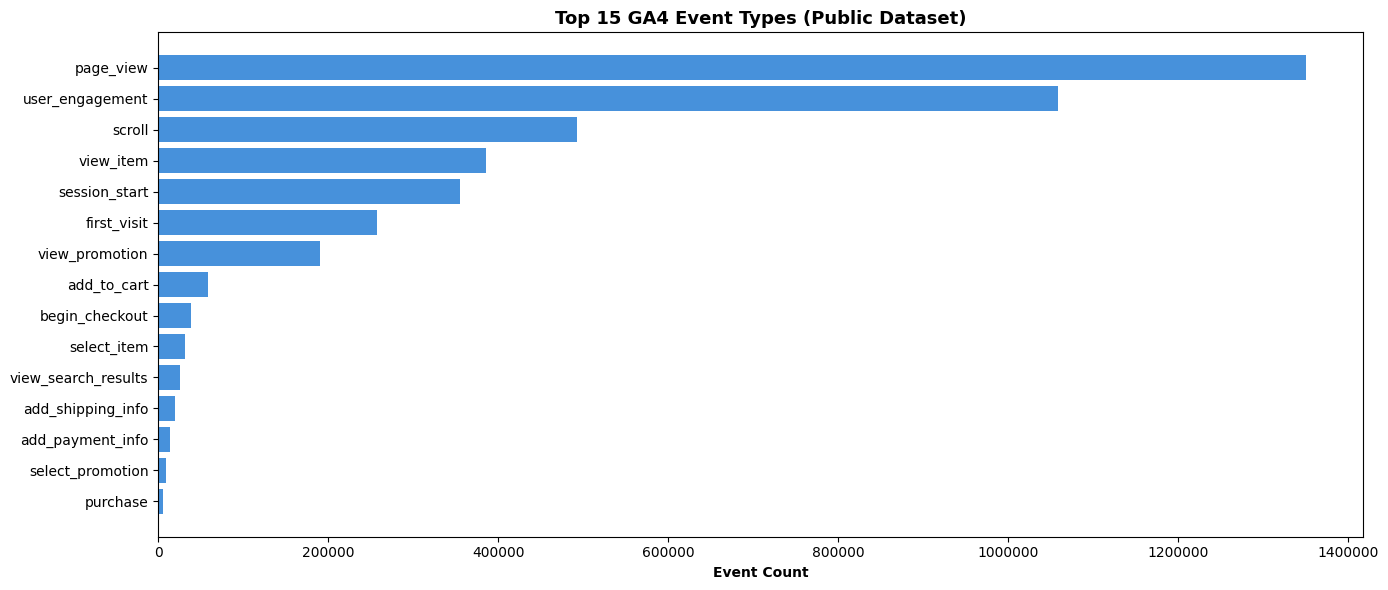

In [8]:
top_events = events_df.head(15)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(top_events['event_name'][::-1], top_events['event_count'][::-1], color='#1976D2', alpha=0.8)
ax.set_xlabel('Event Count', fontweight='bold')
ax.set_title('Top 15 GA4 Event Types (Public Dataset)', fontsize=13, fontweight='bold')
ax.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

### Unnesting Event Parameters

The `event_params` column is an **ARRAY of STRUCTs** — each element has a `key` (string) and a `value` struct with typed fields (`string_value`, `int_value`, `float_value`, `double_value`). This is GA4's way of attaching arbitrary key-value data to each event.

To access a specific parameter, you [UNNEST](https://cloud.google.com/bigquery/docs/arrays#flattening_arrays) the array and filter by key:

```sql
SELECT
    (SELECT value.string_value FROM UNNEST(event_params) WHERE key = 'page_title') AS page_title
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
```

This correlated subquery pattern is the standard way to extract event parameters — you'll use it constantly with GA4 data.

> **Documentation:** [Working with arrays in Standard SQL](https://cloud.google.com/bigquery/docs/arrays)

In [9]:
params_df = bq.query(f'''
    SELECT
        ep.key,
        COUNT(*) AS occurrences,
        COUNTIF(ep.value.string_value IS NOT NULL) AS has_string,
        COUNTIF(ep.value.int_value IS NOT NULL) AS has_int,
        COUNTIF(ep.value.float_value IS NOT NULL) AS has_float,
        COUNTIF(ep.value.double_value IS NOT NULL) AS has_double
    FROM `{GA4_PUBLIC_TABLE}`,
    UNNEST(event_params) AS ep
    GROUP BY ep.key
    ORDER BY occurrences DESC
''').to_dataframe()

print(f'Distinct parameter keys: {len(params_df)}\n')
print(params_df.to_string(index=False))

Distinct parameter keys: 34

                  key  occurrences  has_string  has_int  has_float  has_double
    ga_session_number      4295584           0  4295584          0           0
        ga_session_id      4295584           0  4295584          0           0
        page_location      4295584     4295584        0          0           0
           page_title      4276104     4274636        0          0           0
engaged_session_event      4116237           0  4116237          0           0
      session_engaged      3996312     3682921   313391          0           0
           debug_mode      3682991           0  3682991          0           0
        page_referrer      3206512     1127778        0          0           0
             all_data      2828174           0        0          0           0
          clean_event      2828040     2828040        0          0           0
 engagement_time_msec      2431818           0  2431818          0           0
               medium  

In [10]:
page_views_df = bq.query(f'''
    SELECT
        event_date,
        TIMESTAMP_MICROS(event_timestamp) AS event_time,
        user_pseudo_id,
        (SELECT value.string_value FROM UNNEST(event_params) WHERE key = 'page_title') AS page_title,
        (SELECT value.string_value FROM UNNEST(event_params) WHERE key = 'page_location') AS page_location,
        (SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'engagement_time_msec') AS engagement_time_msec
    FROM `{GA4_PUBLIC_TABLE}`
    WHERE event_name = 'page_view'
    ORDER BY event_timestamp
    LIMIT 10
''').to_dataframe()

print('Sample page_view events with extracted parameters:\n')
print(page_views_df.to_string(index=False))

Sample page_view events with extracted parameters:

event_date                       event_time      user_pseudo_id                                          page_title                                                                      page_location  engagement_time_msec
  20201101 2020-11-01 00:00:04.579566+00:00 82023966.6010891291                                                Home                                           https://shop.googlemerchandisestore.com/                  <NA>
  20201101 2020-11-01 00:00:06.427147+00:00  7754124.2052719725         Bags | Lifestyle | Google Merchandise Store             https://shop.googlemerchandisestore.com/Google+Redesign/Lifestyle/Bags                  <NA>
  20201101 2020-11-01 00:00:27.483279+00:00 50214262.5614106866                                    Page Unavailable        https://shop.googlemerchandisestore.com/Google Redesign/Lifestyle/Drinkware                  <NA>
  20201101 2020-11-01 00:00:43.867564+00:00 82023966.6010891291 

### Traffic Sources

The `traffic_source` struct tells you how users arrived at the site — critical for the continuous query use cases we'll build later.

| Field | Meaning | Examples |
|-------|---------|----------|
| `source` | Where traffic came from | `google`, `facebook`, `(direct)` |
| `medium` | The marketing medium | `organic`, `cpc`, `referral`, `(none)` |
| `name` | Campaign name | Specific campaign identifiers |

In [11]:
traffic_df = bq.query(f'''
    SELECT
        traffic_source.source,
        traffic_source.medium,
        COUNT(DISTINCT user_pseudo_id) AS unique_users,
        COUNT(*) AS total_events,
        COUNTIF(event_name = 'purchase') AS purchases
    FROM `{GA4_PUBLIC_TABLE}`
    GROUP BY traffic_source.source, traffic_source.medium
    ORDER BY unique_users DESC
    LIMIT 15
''').to_dataframe()

print('Top 15 traffic sources:\n')
print(traffic_df.to_string(index=False))

Top 15 traffic sources:

                         source         medium  unique_users  total_events  purchases
                         google        organic        103487       1323449       1454
                       (direct)         (none)         75951        989684       1251
                        <Other>        <Other>         51037        597476        606
                        <Other>       referral         32880        412242        557
shop.googlemerchandisestore.com       referral         26065        365774        701
                 (data deleted) (data deleted)         17948        308624        830
                         google            cpc         15527        176963        166
                        <Other>        organic         10095        115950        118
                        <Other> (data deleted)           393          5293          9
                 (data deleted)       referral             3            71          0
                         goog

---
## 2. E-Commerce Funnel

For the continuous query demos, we'll detect funnel drop-offs. Let's first understand the e-commerce funnel in this dataset — how users move from viewing products to completing purchases.

The GA4 e-commerce funnel typically follows this path:

```
page_view → view_item → add_to_cart → begin_checkout → purchase
```

Each step has fewer users than the previous one — the "funnel" shape. The ratio between steps is the **conversion rate** at each stage.

In [12]:
funnel_df = bq.query(f'''
    WITH user_events AS (
        SELECT
            user_pseudo_id,
            COUNTIF(event_name = 'page_view') AS page_views,
            COUNTIF(event_name = 'view_item') AS view_items,
            COUNTIF(event_name = 'add_to_cart') AS add_to_carts,
            COUNTIF(event_name = 'begin_checkout') AS begin_checkouts,
            COUNTIF(event_name = 'purchase') AS purchases
        FROM `{GA4_PUBLIC_TABLE}`
        GROUP BY user_pseudo_id
    )
    SELECT
        COUNTIF(page_views > 0) AS users_with_page_view,
        COUNTIF(view_items > 0) AS users_with_view_item,
        COUNTIF(add_to_carts > 0) AS users_with_add_to_cart,
        COUNTIF(begin_checkouts > 0) AS users_with_begin_checkout,
        COUNTIF(purchases > 0) AS users_with_purchase
    FROM user_events
''').to_dataframe()

funnel_steps = ['page_view', 'view_item', 'add_to_cart', 'begin_checkout', 'purchase']
funnel_values = funnel_df.iloc[0].values.tolist()

print('E-Commerce Funnel (unique users at each stage):\n')
for step, val in zip(funnel_steps, funnel_values):
    pct = val / funnel_values[0] * 100
    bar = '█' * int(pct / 2)
    print(f'  {step:<20s} {val:>8,}  ({pct:5.1f}%)  {bar}')

E-Commerce Funnel (unique users at each stage):

  page_view             269,792  (100.0%)  ██████████████████████████████████████████████████
  view_item              61,252  ( 22.7%)  ███████████
  add_to_cart            12,545  (  4.6%)  ██
  begin_checkout          9,715  (  3.6%)  █
  purchase                4,419  (  1.6%)  


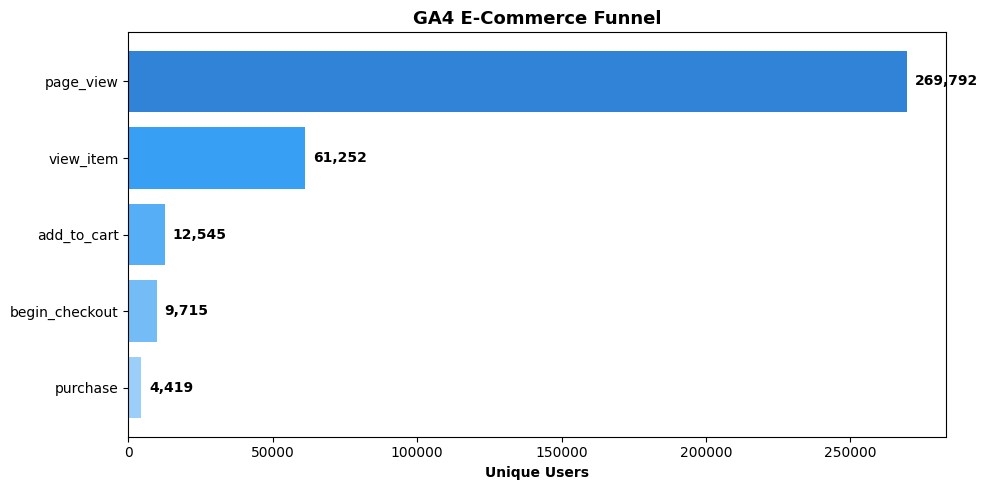

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1976D2', '#2196F3', '#42A5F5', '#64B5F6', '#90CAF9']
bars = ax.barh(funnel_steps[::-1], funnel_values[::-1], color=colors[::-1], alpha=0.9)

for bar, val in zip(bars, funnel_values[::-1]):
    ax.text(bar.get_width() + max(funnel_values) * 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Unique Users', fontweight='bold')
ax.set_title('GA4 E-Commerce Funnel', fontsize=13, fontweight='bold')
ax.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

### Daily Event Volume

In [14]:
daily_df = bq.query(f'''
    SELECT
        PARSE_DATE('%Y%m%d', event_date) AS date,
        COUNT(*) AS total_events,
        COUNTIF(event_name = 'page_view') AS page_views,
        COUNTIF(event_name = 'purchase') AS purchases,
        COUNT(DISTINCT user_pseudo_id) AS unique_users
    FROM `{GA4_PUBLIC_TABLE}`
    GROUP BY date
    ORDER BY date
''').to_dataframe()

print(f'Date range: {daily_df["date"].min()} to {daily_df["date"].max()}')
print(f'Total days: {len(daily_df)}')
print(f'\nDaily averages:')
print(f'  Events:     {daily_df["total_events"].mean():,.0f}')
print(f'  Page views: {daily_df["page_views"].mean():,.0f}')
print(f'  Purchases:  {daily_df["purchases"].mean():,.0f}')
print(f'  Users:      {daily_df["unique_users"].mean():,.0f}')

Date range: 2020-11-01 to 2021-01-31
Total days: 92

Daily averages:
  Events:     46,691
  Page views: 14,679
  Purchases:  62
  Users:      3,468


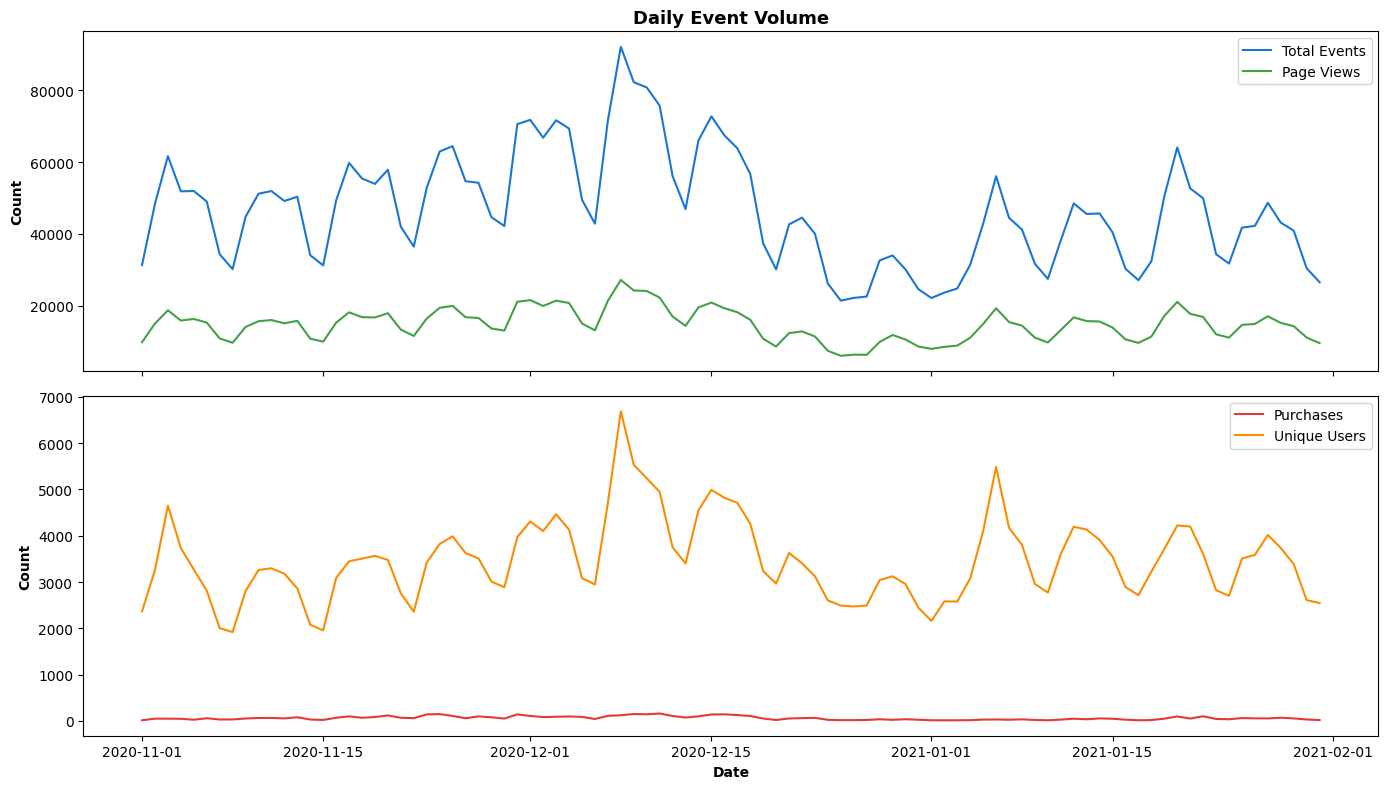

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(daily_df['date'], daily_df['total_events'], color='#1976D2', linewidth=1.5, label='Total Events')
axes[0].plot(daily_df['date'], daily_df['page_views'], color='#43A047', linewidth=1.5, label='Page Views')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('Daily Event Volume', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].ticklabel_format(style='plain', axis='y')

axes[1].plot(daily_df['date'], daily_df['purchases'], color='#E53935', linewidth=1.5, label='Purchases')
axes[1].plot(daily_df['date'], daily_df['unique_users'], color='#FB8C00', linewidth=1.5, label='Unique Users')
axes[1].set_xlabel('Date', fontweight='bold')
axes[1].set_ylabel('Count', fontweight='bold')
axes[1].legend()
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

---
## 3. Connecting a Real GA4 Property

The public dataset is a static snapshot — great for learning, but no new data arrives. For production, you connect your own GA4 property to BigQuery:

### Setup Steps

1. **Link GA4 to BigQuery** in the GA4 Admin console:
   - Go to **Admin → Product Links → BigQuery Links**
   - Click **Link** and select your GCP project
   - Choose your export type (see below)

2. **Choose export frequency:**

   | Export Type | Table Pattern | Latency | Best For |
   |-------------|--------------|---------|----------|
   | **Daily** | `events_YYYYMMDD` | Next day | Batch analytics, reporting |
   | **Streaming** | `events_intraday_YYYYMMDD` | Near real-time | Continuous queries, real-time dashboards |

   For continuous queries, you need **streaming export** — it creates `events_intraday_*` tables that update in near-real-time as users interact with your site.

3. **Select events to export** — you can export all events or filter to specific ones.

### What Changes for Continuous Queries

With a real GA4 streaming export:
- Data arrives automatically — no simulation needed
- Point your continuous query at `events_intraday_*` instead of our `events_streaming` table
- Everything else (the SQL, destination tables, alerting logic) stays the same

### Documentation

| Topic | Link |
|-------|------|
| Set up BigQuery Export | [Setup guide](https://support.google.com/analytics/answer/9358801) |
| BigQuery Export schema | [Schema reference](https://support.google.com/analytics/answer/7029846) |
| Streaming vs daily export | [Export frequency](https://support.google.com/analytics/answer/9823238) |
| GA4 demo dataset | [Public dataset](https://developers.google.com/analytics/bigquery/web-ecommerce-demo-dataset) |

---
## 4. Create Demo Dataset and Tables

Since the public dataset is static, we need our own tables to demonstrate continuous queries with live data. We create:

- **`events_streaming`** — receives simulated GA4 events via load jobs (source table)
- **`funnel_events`** — destination for row-by-row funnel event classification (instant results)
- **`purchase_alerts`** — destination for row-by-row purchase/checkout alerts (instant results)
- **`funnel_alerts`** — destination for windowed funnel conversion rates (1-minute TUMBLE windows)
- **`traffic_anomalies`** — destination for windowed traffic volume monitoring (1-minute TUMBLE windows)

### Schema Mapping

We use a simplified but faithful schema that captures the key GA4 columns:

| Our Column | GA4 Equivalent | Purpose |
|------------|---------------|----------|
| `event_timestamp` | `event_timestamp` | When the event occurred |
| `event_name` | `event_name` | Type of event |
| `user_pseudo_id` | `user_pseudo_id` | Anonymous user identifier |
| `traffic_source` | `traffic_source.source` | Where the user came from |
| `traffic_medium` | `traffic_source.medium` | Marketing medium |
| `country` | `geo.country` | User's country |
| `device_category` | `device.category` | desktop, mobile, tablet |
| `page_title` | `event_params[page_title]` | Page the user was on |
| `event_value` | `event_params[value]` | Numeric value (e.g., purchase amount) |
| `stream_insert_time` | — | When we inserted the row (for demo tracking) |

In [16]:
dataset = bigquery.Dataset(f'{BQ_PROJECT}.{BQ_DATASET}')
dataset.location = BQ_LOCATION
dataset = bq.create_dataset(dataset, exists_ok=True)
print(f'Dataset ready: {BQ_PROJECT}.{BQ_DATASET}')

Dataset ready: statmike-mlops-349915.ga4_continuous_queries


In [17]:
EVENTS_TABLE_ID = f'{BQ_PROJECT}.{BQ_DATASET}.{BQ_TABLE_EVENTS}'
FUNNEL_EVENTS_TABLE_ID = f'{BQ_PROJECT}.{BQ_DATASET}.{BQ_TABLE_FUNNEL_EVENTS}'
PURCHASE_ALERTS_TABLE_ID = f'{BQ_PROJECT}.{BQ_DATASET}.{BQ_TABLE_PURCHASE_ALERTS}'
FUNNEL_TABLE_ID = f'{BQ_PROJECT}.{BQ_DATASET}.{BQ_TABLE_FUNNEL}'
ANOMALY_TABLE_ID = f'{BQ_PROJECT}.{BQ_DATASET}.{BQ_TABLE_ANOMALY}'

bq.query(f'''
    CREATE TABLE IF NOT EXISTS `{EVENTS_TABLE_ID}` (
        event_timestamp TIMESTAMP,
        event_name STRING,
        user_pseudo_id STRING,
        traffic_source STRING,
        traffic_medium STRING,
        country STRING,
        device_category STRING,
        page_title STRING,
        event_value FLOAT64,
        items_count INT64,
        stream_insert_time TIMESTAMP DEFAULT CURRENT_TIMESTAMP()
    )
''').result()

bq.query(f'''
    CREATE TABLE IF NOT EXISTS `{FUNNEL_EVENTS_TABLE_ID}` (
        event_timestamp TIMESTAMP,
        event_name STRING,
        user_pseudo_id STRING,
        traffic_source STRING,
        traffic_medium STRING,
        device_category STRING,
        funnel_stage INT64,
        detected_at TIMESTAMP
    )
''').result()

bq.query(f'''
    CREATE TABLE IF NOT EXISTS `{PURCHASE_ALERTS_TABLE_ID}` (
        event_timestamp TIMESTAMP,
        event_name STRING,
        user_pseudo_id STRING,
        traffic_source STRING,
        traffic_medium STRING,
        country STRING,
        event_value FLOAT64,
        items_count INT64,
        detected_at TIMESTAMP
    )
''').result()

bq.query(f'''
    CREATE TABLE IF NOT EXISTS `{FUNNEL_TABLE_ID}` (
        window_start TIMESTAMP,
        window_end TIMESTAMP,
        traffic_source STRING,
        traffic_medium STRING,
        page_views INT64,
        purchases INT64,
        conversion_rate FLOAT64,
        alert_type STRING,
        detected_at TIMESTAMP
    )
''').result()

bq.query(f'''
    CREATE TABLE IF NOT EXISTS `{ANOMALY_TABLE_ID}` (
        window_start TIMESTAMP,
        window_end TIMESTAMP,
        traffic_source STRING,
        traffic_medium STRING,
        event_count INT64,
        avg_event_count FLOAT64,
        stddev_event_count FLOAT64,
        z_score FLOAT64,
        anomaly_type STRING,
        detected_at TIMESTAMP
    )
''').result()

print('Tables ready:')
for table_name in [BQ_TABLE_EVENTS, BQ_TABLE_FUNNEL_EVENTS, BQ_TABLE_PURCHASE_ALERTS, BQ_TABLE_FUNNEL, BQ_TABLE_ANOMALY]:
    table_id = f'{BQ_PROJECT}.{BQ_DATASET}.{table_name}'
    t = bq.get_table(table_id)
    print(f'  {table_name:<25s} {len(t.schema):>3} columns  {t.num_rows:>8,} rows')

Tables ready:
  events_streaming           11 columns         0 rows
  funnel_events               8 columns         0 rows
  purchase_alerts             9 columns         0 rows
  funnel_alerts               9 columns         0 rows
  traffic_anomalies          10 columns         0 rows


---
## 5. Enterprise Reservation

Continuous queries require [BigQuery Enterprise edition](https://cloud.google.com/bigquery/docs/editions-intro), enabled through [reservations](https://cloud.google.com/bigquery/docs/reservations-intro) — pools of compute capacity (slots) allocated to your project.

### Key Concepts

| Concept | Description |
|---------|-------------|
| **[Reservation](https://cloud.google.com/bigquery/docs/reservations-intro)** | A pool of BigQuery [slots](https://cloud.google.com/bigquery/docs/slots) (compute units) |
| **Assignment** | Maps a reservation to a project and a job type |
| **Edition** | Enterprise is required for continuous queries |
| **Job type** | `CONTINUOUS` for continuous queries (separate from `QUERY`) |

### CONTINUOUS vs QUERY Assignments

| Aspect | QUERY | CONTINUOUS |
|--------|-------|------------|
| Purpose | Ad-hoc queries, exports | Long-running continuous queries |
| Lifecycle | Jobs start and finish | Jobs run indefinitely |
| Max slots | Up to reservation capacity | 500 slots max per reservation |
| Mixing | Cannot share reservation with CONTINUOUS | Cannot share reservation with QUERY |

### Cost

Slots are billed per-second at [Enterprise on-demand rates](https://cloud.google.com/bigquery/pricing#editions_pricing) while the reservation exists. We create 100 slots. **The reservation is deleted in the cleanup section to stop billing.**

> **Documentation:** [Reservations overview](https://cloud.google.com/bigquery/docs/reservations-intro) · [Editions comparison](https://cloud.google.com/bigquery/docs/editions-intro)

In [18]:
parent = f'projects/{PROJECT_ID}/locations/{BQ_LOCATION}'

created = False
try:
    reservation = reservation_client.create_reservation(
        parent=parent,
        reservation_id=RESERVATION_ID,
        reservation=bigquery_reservation_v1.Reservation(
            slot_capacity=RESERVATION_SLOTS,
            edition=bigquery_reservation_v1.Edition.ENTERPRISE,
        ),
    )
    created = True
    print(f'Created reservation: {reservation.name}')
    print(f'  Slots:   {reservation.slot_capacity}')
    print(f'  Edition: ENTERPRISE')
except AlreadyExists:
    reservation = reservation_client.get_reservation(
        name=f'{parent}/reservations/{RESERVATION_ID}'
    )
    print(f'Reservation exists: {reservation.name}')

Created reservation: projects/statmike-mlops-349915/locations/US/reservations/ga4-continuous-demo
  Slots:   100
  Edition: ENTERPRISE


In [19]:
try:
    assignment = reservation_client.create_assignment(
        parent=reservation.name,
        assignment=bigquery_reservation_v1.Assignment(
            job_type=bigquery_reservation_v1.Assignment.JobType.CONTINUOUS,
            assignee=f'projects/{PROJECT_ID}',
        ),
    )
    print(f'Created assignment: {assignment.name}')
    print(f'  Job type: CONTINUOUS')
    print(f'  Assignee: {PROJECT_ID}')
    created = True
except AlreadyExists:
    assignments = list(reservation_client.list_assignments(parent=reservation.name))
    assignment = assignments[0]
    print(f'Assignment exists: {assignment.name}')

print(f'\nReservation ready:')
print(f'  Reservation: {RESERVATION_ID} ({RESERVATION_SLOTS} slots, Enterprise)')
print(f'  Assignment:  CONTINUOUS → {PROJECT_ID}')

if created:
    print(f'\nWaiting 120s for assignment to propagate...')
    time.sleep(120)
    print('Ready.')
else:
    print('\nReservation and assignment already exist — no wait needed.')

Created assignment: projects/statmike-mlops-349915/locations/US/reservations/ga4-continuous-demo/assignments/10498276144515700580
  Job type: CONTINUOUS
  Assignee: statmike-mlops-349915

Reservation ready:
  Reservation: ga4-continuous-demo (100 slots, Enterprise)
  Assignment:  CONTINUOUS → statmike-mlops-349915

Waiting 120s for assignment to propagate...
Ready.


---
## 6. Stream Events

We simulate GA4's [streaming export](https://support.google.com/analytics/answer/9358801) by reading real events from the public dataset and replaying them into our own table using BigQuery [load jobs](https://cloud.google.com/bigquery/docs/loading-data) (`load_table_from_json()`).

This section reads events from the public dataset and **starts streaming them immediately** — so data is already flowing when we create continuous queries in Section 7.

### What Data Can Continuous Queries See?

[Continuous queries](https://cloud.google.com/bigquery/docs/continuous-queries-introduction) can process data written to BigQuery tables by any of these methods:

| Method | Example |
|--------|---------|
| [Storage Write API](https://cloud.google.com/bigquery/docs/write-api) | GA4 streaming export, Dataflow writes |
| [`tabledata.insertAll`](https://cloud.google.com/bigquery/docs/streaming-data-into-bigquery) | Legacy streaming inserts (`insert_rows_json()`) |
| [Batch load](https://cloud.google.com/bigquery/docs/loading-data) | `load_table_from_json()`, `bq load` — **used in this demo** |
| [DML statements](https://cloud.google.com/bigquery/docs/reference/standard-sql/dml-syntax) | `INSERT`, `DELETE`, `UPDATE`, `MERGE` |
| Batch query results | `INSERT INTO ... SELECT` writing to a permanent table |
| [Pub/Sub subscription](https://cloud.google.com/pubsub/docs/bigquery-streaming) | Pub/Sub BigQuery subscriptions |
| [Dataflow](https://cloud.google.com/dataflow/docs/overview) | Dataflow-to-BigQuery writes |
| [Datastream](https://cloud.google.com/datastream/docs/overview) | Datastream append-only write mode |

We use **load jobs** for this demo because they write directly to managed storage, making data immediately visible to continuous queries with no propagation delay. Streaming inserts (`tabledata.insertAll`) are technically supported but write to a buffer that introduces latency — windowed (TUMBLE) queries can miss data that hasn't propagated by window close.

> **In production:** GA4's streaming export uses the [Storage Write API](https://cloud.google.com/bigquery/docs/write-api), which also writes to managed storage. Any of the methods above would work — continuous queries process new data regardless of how it arrives.

### How It Works

| Aspect | Our Simulation | Real GA4 Streaming Export |
|--------|---------------|-------------------------|
| **Source** | Public GA4 dataset (replayed) | Live user interactions |
| **Insert method** | `load_table_from_json()` | Storage Write API |
| **Batch size** | ~100 rows per batch | Varies by traffic volume |
| **Frequency** | Every ~3-5 seconds (load job overhead) | Continuous, sub-second |
| **Timestamps** | Remapped to now | Real-time |

The continuous queries don't care whether events come from GA4 or our simulation — they process whatever arrives in the table.

### Read Events from Public Dataset

In [33]:
print('Reading events from public GA4 dataset...')
start = time.perf_counter()

source_df = bq.query(f'''
    SELECT
        TIMESTAMP_MICROS(event_timestamp) AS event_timestamp,
        event_name,
        user_pseudo_id,
        traffic_source.source AS traffic_source,
        traffic_source.medium AS traffic_medium,
        geo.country AS country,
        device.category AS device_category,
        (SELECT value.string_value FROM UNNEST(event_params) WHERE key = 'page_title') AS page_title,
        (SELECT value.double_value FROM UNNEST(event_params) WHERE key = 'value') AS event_value,
        (SELECT COUNT(*) FROM UNNEST(items)) AS items_count
    FROM `{GA4_PUBLIC_TABLE}`
    ORDER BY event_timestamp
    LIMIT 5000
''').to_dataframe()

elapsed = time.perf_counter() - start
print(f'Read {len(source_df):,} events in {elapsed:.1f}s')
print(f'\nEvent distribution:')
print(source_df['event_name'].value_counts().head(10).to_string())

Reading events from public GA4 dataset...
Read 5,000 events in 6.2s

Event distribution:
event_name
page_view              1528
user_engagement        1331
session_start           529
scroll                  473
first_visit             414
view_item               409
view_promotion          209
view_search_results      29
begin_checkout           22
add_shipping_info        22


### Start Background Streaming

Start replaying events into `events_streaming` in a background thread using load jobs. Each batch writes directly to managed storage, making data immediately visible to continuous queries. Two **anomaly bursts** (10x normal batch size) are injected at batches 15 and 35 to test CQ 4's traffic anomaly detection.

In [34]:
import threading
from google.cloud.bigquery import LoadJobConfig

BATCH_SIZE = 100       # events per batch
BATCH_DELAY = 1        # seconds between batches (load job overhead ~2-4s provides additional spacing)
ANOMALY_MULTIPLIER = 10     # repeat batch events 10x to simulate traffic spike

stream_start = datetime.datetime.now(datetime.timezone.utc)
stream_start_ts = stream_start.strftime('%Y-%m-%d %H:%M:%S UTC')
stream_state = {'inserted': 0, 'done': False, 'errors': 0, 'anomaly_times': []}
load_config = LoadJobConfig(
    schema=[
        bigquery.SchemaField('event_timestamp', 'TIMESTAMP'),
        bigquery.SchemaField('event_name', 'STRING'),
        bigquery.SchemaField('user_pseudo_id', 'STRING'),
        bigquery.SchemaField('traffic_source', 'STRING'),
        bigquery.SchemaField('traffic_medium', 'STRING'),
        bigquery.SchemaField('country', 'STRING'),
        bigquery.SchemaField('device_category', 'STRING'),
        bigquery.SchemaField('page_title', 'STRING'),
        bigquery.SchemaField('event_value', 'FLOAT64'),
        bigquery.SchemaField('items_count', 'INT64'),
        bigquery.SchemaField('stream_insert_time', 'TIMESTAMP'),
    ],
)

def stream_events(anomaly_batches):
    total = len(source_df)
    for batch_idx, batch_start in enumerate(range(0, total, BATCH_SIZE)):
        base_batch = source_df.iloc[batch_start:batch_start + BATCH_SIZE]

        if batch_idx in anomaly_batches:
            batch = pd.concat([base_batch] * ANOMALY_MULTIPLIER, ignore_index=True).copy()
            stream_state['anomaly_times'].append(datetime.datetime.now(datetime.timezone.utc).isoformat())
        else:
            batch = base_batch.copy()

        now = datetime.datetime.now(datetime.timezone.utc)
        batch['event_timestamp'] = [now - datetime.timedelta(seconds=j * 0.5) for j in range(len(batch))]

        rows = []
        for _, row in batch.iterrows():
            rows.append({
                'event_timestamp': row['event_timestamp'].isoformat(),
                'event_name': row['event_name'],
                'user_pseudo_id': row['user_pseudo_id'],
                'traffic_source': row['traffic_source'] if pd.notna(row['traffic_source']) else None,
                'traffic_medium': row['traffic_medium'] if pd.notna(row['traffic_medium']) else None,
                'country': row['country'] if pd.notna(row['country']) else None,
                'device_category': row['device_category'] if pd.notna(row['device_category']) else None,
                'page_title': row['page_title'] if pd.notna(row['page_title']) else None,
                'event_value': float(row['event_value']) if pd.notna(row['event_value']) else None,
                'items_count': int(row['items_count']) if pd.notna(row['items_count']) else 0,
                'stream_insert_time': now.isoformat(),
            })

        try:
            load_job = bq.load_table_from_json(rows, EVENTS_TABLE_ID, job_config=load_config)
            load_job.result()
            stream_state['inserted'] += len(rows)
        except Exception:
            stream_state['errors'] += 1

        time.sleep(BATCH_DELAY)

    stream_state['done'] = True

ANOMALY_BATCHES = {15, 35}
thread = threading.Thread(target=stream_events, args=(ANOMALY_BATCHES,), daemon=True)
thread.start()

print(f'Background streaming started at {stream_start_ts}')
print(f'  {len(source_df):,} events, {BATCH_SIZE}/batch, load jobs to managed storage')
print(f'  Anomaly bursts at batches {sorted(ANOMALY_BATCHES)} ({ANOMALY_MULTIPLIER}x events each)')
print(f'  Estimated duration: ~{len(source_df) // BATCH_SIZE * 4}s (load job overhead ~2-4s/batch)')
print(f'\nData is now flowing into {BQ_TABLE_EVENTS}.')
print(f'Continue to Section 7 to create continuous queries while data streams.')

Background streaming started at 2026-05-22 13:20:01 UTC
  5,000 events, 100/batch, load jobs to managed storage
  Anomaly bursts at batches [15, 35] (10x events each)
  Estimated duration: ~200s (load job overhead ~2-4s/batch)

Data is now flowing into events_streaming.
Continue to Section 7 to create continuous queries while data streams.


---
## 7. Continuous Queries

> **Data is already flowing.** The background streaming thread from Section 6 is loading events into `events_streaming` right now. Creating CQs here means they immediately have fresh data to process.

Now for the main event. A [continuous query](https://cloud.google.com/bigquery/docs/continuous-queries-introduction) is a standard `INSERT INTO ... SELECT` statement that runs indefinitely, processing new rows as they arrive. You make it continuous by setting `continuous = True` in the [job configuration](https://cloud.google.com/bigquery/docs/reference/rest/v2/Job#jobconfigurationquery). The Python BigQuery client doesn't expose this flag natively, so we set it via `job_config._properties["query"]["continuous"] = True`.

### Two Processing Patterns

| Pattern | SQL | Latency | When to Use |
|---------|-----|---------|-------------|
| **Row-by-row** | `SELECT FROM APPENDS()` | Seconds | Classify events, instant alerts, data enrichment |
| **Windowed** | `SELECT FROM TUMBLE(TABLE cte)` | Window duration | Conversion rates, traffic trends, anomaly detection |

**Row-by-row** queries process each new row individually — results appear in the destination table within seconds of a new event arriving. **Windowed** queries aggregate rows into non-overlapping time windows (using `TUMBLE`) — results appear when each window closes.

### Key Components

| Component | Purpose |
|-----------|----------|
| [`APPENDS(TABLE, timestamp)`](https://cloud.google.com/bigquery/docs/reference/standard-sql/table-functions#appends) | Table-valued function that returns only rows added since the given timestamp. Each row is processed exactly once. |
| [`TUMBLE(TABLE, col, interval)`](https://cloud.google.com/bigquery/docs/reference/standard-sql/time-series-functions#tumble) | Table-valued function that creates non-overlapping time windows. Adds `window_start` and `window_end` columns. Results emit when each window closes. |
| `_CHANGE_TIMESTAMP` | BigQuery system column — the **only** supported timestamp column for `TUMBLE`. User-defined timestamp columns are not supported. |
| `"continuous": true` | Job config field that makes the query run indefinitely instead of completing after one pass. |
| `INSERT INTO` | Continuous queries must write to a destination — a BigQuery table, [Pub/Sub](https://cloud.google.com/bigquery/docs/continuous-queries-pub-sub), [Bigtable](https://cloud.google.com/bigquery/docs/continuous-queries-bigtable), or [Spanner](https://cloud.google.com/bigquery/docs/continuous-queries-spanner). |

### Composing `TUMBLE` + `APPENDS`

For windowed queries, `APPENDS()` goes in a **CTE** (Common Table Expression), and the CTE is passed to `TUMBLE()` with the `TABLE` keyword:

```sql
WITH new_events AS (
    SELECT _CHANGE_TIMESTAMP AS change_ts, col1
    FROM APPENDS(TABLE `source_table`, CURRENT_TIMESTAMP() - INTERVAL 10 MINUTE)
)
SELECT window_start, window_end, col1, COUNT(*)
FROM TUMBLE(TABLE new_events, "change_ts", INTERVAL 1 MINUTE)
GROUP BY window_start, window_end, col1
```

> **Important:** `TUMBLE` only supports `_CHANGE_TIMESTAMP` (a BigQuery system column) as its timestamp descriptor — not user-defined columns.

We create **4 continuous queries** — 2 row-by-row and 2 windowed — so the live dashboard in Section 8 can show the contrast between instant and periodic results.

> **Documentation:** [Continuous queries](https://cloud.google.com/bigquery/docs/continuous-queries) · [APPENDS()](https://cloud.google.com/bigquery/docs/reference/standard-sql/table-functions#appends) · [TUMBLE()](https://cloud.google.com/bigquery/docs/reference/standard-sql/time-series-functions#tumble)

### Clear Previous Continuous Queries

If the kernel was restarted, CQ jobs from previous sessions may still be running in BigQuery. Cancel them so they don't compete for slots or produce duplicate results.

In [35]:
cq_jobs = []

print('Checking for zombie continuous queries from previous sessions...')
zombie_df = bq.query(f'''
    SELECT job_id
    FROM `{BQ_PROJECT}.region-{BQ_LOCATION.lower()}`.INFORMATION_SCHEMA.JOBS
    WHERE state = 'RUNNING'
        AND creation_time > TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 7 DAY)
        AND LOWER(query) LIKE '%appends%'
        AND LOWER(query) LIKE '%insert into%'
        AND LOWER(query) LIKE '%{BQ_DATASET.lower()}%'
''').to_dataframe()

cancelled = 0
for _, row in zombie_df.iterrows():
    try:
        bq.cancel_job(row['job_id'], location=BQ_LOCATION)
        print(f'  Cancelled: {row["job_id"]}')
        cancelled += 1
    except Exception:
        pass

if cancelled:
    print(f'\nCancelled {cancelled} zombie CQ(s) — clean slate for new CQs.')
else:
    print('No zombie CQs found — clean slate.')

Checking for zombie continuous queries from previous sessions...
  Cancelled: 967d7952-881f-473f-b5b1-357a772262b9
  Cancelled: 64ded545-e807-4b3c-9c42-1ab179ce3f4c
  Cancelled: a1acf974-b016-498b-bd91-c79a3a776d24
  Cancelled: 6ae2a8e4-8e7a-4437-8b1f-ea81db44663a

Cancelled 4 zombie CQ(s) — clean slate for new CQs.


In [36]:
def create_continuous_query(sql):
    job_config = bigquery.QueryJobConfig()
    job_config._properties["query"]["continuous"] = True
    job = bq.query(sql, job_config=job_config)
    cq_jobs.append(job.job_id)
    return job.job_id, job.state

print('create_continuous_query() ready')

create_continuous_query() ready


### CQ 1 — Funnel Event Classification (row-by-row)

Classifies each incoming e-commerce event by funnel stage as it arrives, enriched with **device category** (desktop, mobile, tablet). No windowing — results appear in the destination table within seconds.

| Funnel Stage | Event Name | Stage Number |
|-------------|------------|:------------:|
| Browse | `page_view` | 1 |
| Discover | `view_item` | 2 |
| Intent | `add_to_cart` | 3 |
| Commit | `begin_checkout` | 4 |
| Convert | `purchase` | 5 |

In [37]:
funnel_events_cq_sql = f'''
INSERT INTO `{FUNNEL_EVENTS_TABLE_ID}`
SELECT
    event_timestamp,
    event_name,
    user_pseudo_id,
    traffic_source,
    traffic_medium,
    device_category,
    CASE event_name
        WHEN 'page_view' THEN 1
        WHEN 'view_item' THEN 2
        WHEN 'add_to_cart' THEN 3
        WHEN 'begin_checkout' THEN 4
        WHEN 'purchase' THEN 5
    END AS funnel_stage,
    CURRENT_TIMESTAMP() AS detected_at
FROM APPENDS(
    TABLE `{EVENTS_TABLE_ID}`,
    CURRENT_TIMESTAMP() - INTERVAL 10 MINUTE
)
WHERE event_name IN ('page_view', 'view_item', 'add_to_cart', 'begin_checkout', 'purchase')
'''

print('Creating continuous query: Funnel Event Classification (row-by-row)')
print(f'  Source:      {EVENTS_TABLE_ID}')
print(f'  Destination: {FUNNEL_EVENTS_TABLE_ID}')
print(f'  Pattern:     APPENDS only (no windowing)')
print(f'  Enrichment:  device_category (desktop/mobile/tablet)')
print()

job_id, state = create_continuous_query(funnel_events_cq_sql)
print(f'Continuous query job started: {job_id}')
print(f'  State: {state}')

Creating continuous query: Funnel Event Classification (row-by-row)
  Source:      statmike-mlops-349915.ga4_continuous_queries.events_streaming
  Destination: statmike-mlops-349915.ga4_continuous_queries.funnel_events
  Pattern:     APPENDS only (no windowing)
  Enrichment:  device_category (desktop/mobile/tablet)

Continuous query job started: 7bb3aeeb-edbc-41aa-b6d7-e052a9aea51a
  State: RUNNING


### CQ 2 — Purchase Alerts (row-by-row)

Fires an instant alert for every `purchase` or `begin_checkout` event — the highest-value actions in the funnel. Captures the user, traffic source, country, purchase value, and **item count** for immediate downstream consumption (dashboards, Pub/Sub triggers, ML features).

In [38]:
purchase_alerts_cq_sql = f'''
INSERT INTO `{PURCHASE_ALERTS_TABLE_ID}`
SELECT
    event_timestamp,
    event_name,
    user_pseudo_id,
    traffic_source,
    traffic_medium,
    country,
    event_value,
    items_count,
    CURRENT_TIMESTAMP() AS detected_at
FROM APPENDS(
    TABLE `{EVENTS_TABLE_ID}`,
    CURRENT_TIMESTAMP() - INTERVAL 10 MINUTE
)
WHERE event_name IN ('purchase', 'begin_checkout')
'''

print('Creating continuous query: Purchase Alerts (row-by-row)')
print(f'  Source:      {EVENTS_TABLE_ID}')
print(f'  Destination: {PURCHASE_ALERTS_TABLE_ID}')
print(f'  Pattern:     APPENDS only (no windowing)')
print(f'  Enrichment:  items_count per alert')
print()

job_id, state = create_continuous_query(purchase_alerts_cq_sql)
print(f'Continuous query job started: {job_id}')
print(f'  State: {state}')

Creating continuous query: Purchase Alerts (row-by-row)
  Source:      statmike-mlops-349915.ga4_continuous_queries.events_streaming
  Destination: statmike-mlops-349915.ga4_continuous_queries.purchase_alerts
  Pattern:     APPENDS only (no windowing)
  Enrichment:  items_count per alert

Continuous query job started: e29add9e-5f9c-4a44-97c4-d413ea772590
  State: RUNNING


### CQ 3 — Funnel Conversion Windows (1-minute TUMBLE)

Aggregates `page_view` and `purchase` events into 1-minute tumbling windows by traffic source. Calculates conversion rate and flags low-conversion windows. Results appear when each 1-minute window closes.

In [39]:
funnel_cq_sql = f'''
INSERT INTO `{FUNNEL_TABLE_ID}`
WITH funnel_events AS (
    SELECT
        _CHANGE_TIMESTAMP AS change_ts,
        event_name,
        traffic_source,
        traffic_medium
    FROM APPENDS(
        TABLE `{EVENTS_TABLE_ID}`,
        CURRENT_TIMESTAMP() - INTERVAL 10 MINUTE
    )
    WHERE event_name IN ('page_view', 'purchase')
)
SELECT
    window_start,
    window_end,
    traffic_source,
    traffic_medium,
    COUNTIF(event_name = 'page_view') AS page_views,
    COUNTIF(event_name = 'purchase') AS purchases,
    SAFE_DIVIDE(
        COUNTIF(event_name = 'purchase'),
        COUNTIF(event_name = 'page_view')
    ) AS conversion_rate,
    CASE
        WHEN COUNTIF(event_name = 'page_view') > 10
             AND SAFE_DIVIDE(COUNTIF(event_name = 'purchase'), COUNTIF(event_name = 'page_view')) < 0.01
        THEN 'LOW_CONVERSION'
        ELSE 'NORMAL'
    END AS alert_type,
    CURRENT_TIMESTAMP() AS detected_at
FROM TUMBLE(TABLE funnel_events, "change_ts", INTERVAL 1 MINUTE)
GROUP BY window_start, window_end, traffic_source, traffic_medium
'''

print('Creating continuous query: Funnel Conversion Windows (1-min TUMBLE)')
print(f'  Source:      {EVENTS_TABLE_ID}')
print(f'  Destination: {FUNNEL_TABLE_ID}')
print(f'  Window:      1 minute (tumbling)')
print()

job_id, state = create_continuous_query(funnel_cq_sql)
print(f'Continuous query job started: {job_id}')
print(f'  State: {state}')

Creating continuous query: Funnel Conversion Windows (1-min TUMBLE)
  Source:      statmike-mlops-349915.ga4_continuous_queries.events_streaming
  Destination: statmike-mlops-349915.ga4_continuous_queries.funnel_alerts
  Window:      1 minute (tumbling)

Continuous query job started: f5e0b18a-64d0-42fa-9165-461067b7f62b
  State: RUNNING


### CQ 4 — Traffic Anomaly Detection (1-minute TUMBLE)

Monitors **total event volume** across all traffic sources in 1-minute windows. Flags windows with unusually high event counts — the streaming code injects **traffic bursts** (10x normal volume) at batches 15 and 35, which should appear as `HIGH_VOLUME` anomalies in the output and as red bars on the dashboard.

| Anomaly Type | Condition |
|-------------|-----------|
| `HIGH_VOLUME` | > 2,000 events in a 1-minute window |
| `LOW_VOLUME` | < 200 events in a 1-minute window |
| `NORMAL` | 200–2,000 events |

In [40]:
anomaly_cq_sql = f'''
INSERT INTO `{ANOMALY_TABLE_ID}`
WITH all_events AS (
    SELECT
        _CHANGE_TIMESTAMP AS change_ts,
        'all' AS source_key
    FROM APPENDS(
        TABLE `{EVENTS_TABLE_ID}`,
        CURRENT_TIMESTAMP() - INTERVAL 10 MINUTE
    )
)
SELECT
    window_start,
    window_end,
    source_key AS traffic_source,
    CAST(NULL AS STRING) AS traffic_medium,
    COUNT(*) AS event_count,
    CAST(NULL AS FLOAT64) AS avg_event_count,
    CAST(NULL AS FLOAT64) AS stddev_event_count,
    CAST(NULL AS FLOAT64) AS z_score,
    CASE
        WHEN COUNT(*) > 2000 THEN 'HIGH_VOLUME'
        WHEN COUNT(*) < 200 THEN 'LOW_VOLUME'
        ELSE 'NORMAL'
    END AS anomaly_type,
    CURRENT_TIMESTAMP() AS detected_at
FROM TUMBLE(TABLE all_events, "change_ts", INTERVAL 1 MINUTE)
GROUP BY window_start, window_end, source_key
'''

print('Creating continuous query: Traffic Anomaly Detection (1-min TUMBLE)')
print(f'  Source:      {EVENTS_TABLE_ID}')
print(f'  Destination: {ANOMALY_TABLE_ID}')
print(f'  Window:      1 minute (tumbling)')
print(f'  Thresholds:  HIGH_VOLUME > 2,000 events/window, LOW_VOLUME < 200')
print()

job_id, state = create_continuous_query(anomaly_cq_sql)
print(f'Continuous query job started: {job_id}')
print(f'  State: {state}')

print(f'\n--- All {len(cq_jobs)} continuous queries started ---')
for i, jid in enumerate(cq_jobs, 1):
    job = bq.get_job(jid)
    continuous = job._properties.get('configuration', {}).get('query', {}).get('continuous')
    print(f'  CQ {i}: {job.job_id}  state={job.state}  continuous={continuous}')

Creating continuous query: Traffic Anomaly Detection (1-min TUMBLE)
  Source:      statmike-mlops-349915.ga4_continuous_queries.events_streaming
  Destination: statmike-mlops-349915.ga4_continuous_queries.traffic_anomalies
  Window:      1 minute (tumbling)
  Thresholds:  HIGH_VOLUME > 2,000 events/window, LOW_VOLUME < 200

Continuous query job started: 7e2bdac8-b2e1-49f7-98c9-4f234b2f7f1d
  State: RUNNING

--- All 4 continuous queries started ---
  CQ 1: 7bb3aeeb-edbc-41aa-b6d7-e052a9aea51a  state=RUNNING  continuous=True
  CQ 2: e29add9e-5f9c-4a44-97c4-d413ea772590  state=RUNNING  continuous=True
  CQ 3: f5e0b18a-64d0-42fa-9165-461067b7f62b  state=RUNNING  continuous=True
  CQ 4: 7e2bdac8-b2e1-49f7-98c9-4f234b2f7f1d  state=RUNNING  continuous=True


In [41]:
print('CQ Diagnostic Check')
print('=' * 60)
print(f'Stream state: {stream_state["inserted"]:,} inserted, {stream_state["errors"]} errors, done={stream_state["done"]}')
print(f'Stream start: {stream_start_ts}')
print()

print('Reservation:')
try:
    r = reservation_client.get_reservation(name=f'projects/{PROJECT_ID}/locations/{BQ_LOCATION}/reservations/{RESERVATION_ID}')
    print(f'  {r.name}  slots={r.slot_capacity}  edition={r.edition.name}')
    for a in reservation_client.list_assignments(parent=r.name):
        print(f'  Assignment: {a.job_type.name} → {a.assignee}')
except Exception as e:
    print(f'  ERROR: {e}')
print()

print('CQ Jobs:')
for i, jid in enumerate(cq_jobs, 1):
    try:
        job = bq.get_job(jid)
        continuous = job._properties.get('configuration', {}).get('query', {}).get('continuous')
        error = job.error_result
        stats = job._properties.get('statistics', {}).get('query', {})
        bytes_processed = stats.get('totalBytesProcessed', '?')
        print(f'  CQ {i}: state={job.state}  continuous={continuous}  bytes_processed={bytes_processed}  error={error}')
    except Exception as e:
        print(f'  CQ {i}: FAILED — {e}')
print()

print('Table row counts (all-time / this run):')
for name, tid, ts_col in [
    ('events_streaming',  EVENTS_TABLE_ID,          'stream_insert_time'),
    ('funnel_events',     FUNNEL_EVENTS_TABLE_ID,   'detected_at'),
    ('purchase_alerts',   PURCHASE_ALERTS_TABLE_ID,  'detected_at'),
    ('funnel_alerts',     FUNNEL_TABLE_ID,           'detected_at'),
    ('traffic_anomalies', ANOMALY_TABLE_ID,          'detected_at'),
]:
    try:
        r = bq.query(f"""
            SELECT
                COUNT(*) AS total,
                COUNTIF({ts_col} >= TIMESTAMP('{stream_start_ts}')) AS this_run
            FROM `{tid}`
        """).to_dataframe().iloc[0]
        print(f'  {name:<22s} {int(r["total"]):>8,} total  {int(r["this_run"]):>8,} this run')
    except Exception as e:
        print(f'  {name:<22s} ERROR: {e}')
print('=' * 60)

CQ Diagnostic Check
Stream state: 200 inserted, 0 errors, done=False
Stream start: 2026-05-22 13:20:01 UTC

Reservation:


  projects/statmike-mlops-349915/locations/US/reservations/ga4-continuous-demo  slots=100  edition=ENTERPRISE
  Assignment: CONTINUOUS → projects/statmike-mlops-349915

CQ Jobs:
  CQ 1: state=RUNNING  continuous=True  bytes_processed=?  error=None
  CQ 2: state=RUNNING  continuous=True  bytes_processed=?  error=None
  CQ 3: state=RUNNING  continuous=True  bytes_processed=?  error=None
  CQ 4: state=RUNNING  continuous=True  bytes_processed=?  error=None

Table row counts (all-time / this run):
  events_streaming         13,800 total       200 this run
  funnel_events             5,408 total         0 this run
  purchase_alerts              50 total         0 this run
  funnel_alerts                63 total         0 this run
  traffic_anomalies             8 total         0 this run


---
## 8. Live Dashboard

The 4 continuous queries are running (Section 7) and processing events as they stream in (Section 6). This dashboard polls the CQ destination tables every 8 seconds and visualizes the results across 5 panels:

- **Panel 1** — Cumulative source vs CQ output counts (are CQs keeping up?)
- **Panel 2** — Funnel events by stage, stacked by device category
- **Panel 3** — Purchase alerts with cumulative item count (dual axis)
- **Panel 4** — Per-window conversion rate from TUMBLE windows
- **Panel 5** — Per-window total event volume, color-coded by anomaly type (red = HIGH_VOLUME burst)

The dashboard runs until streaming completes plus 110 seconds to capture the final TUMBLE window.

[  292s]  DONE 6,800/5,000  |  4/4 CQs  |  CQ 1: 5,408  |  CQ 2: 50 (10 items)  |  CQ 3: 7 wins  |  CQ 4: 7 wins


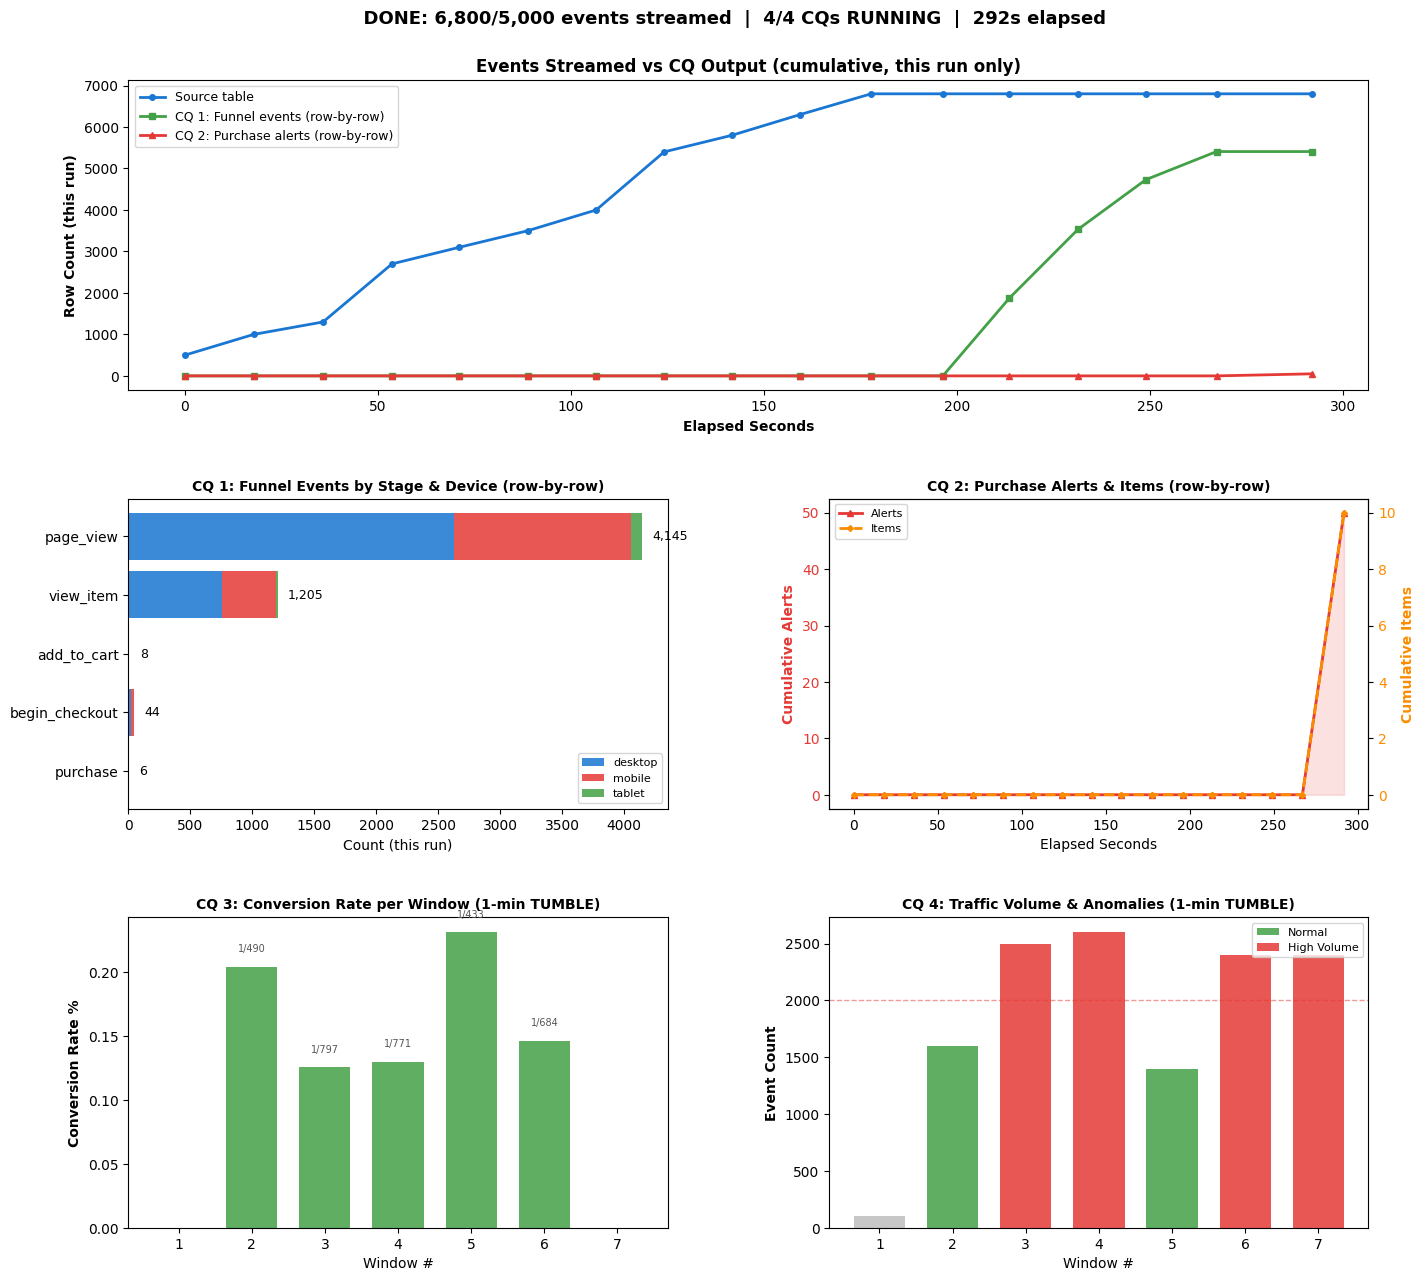


  DASHBOARD COMPLETE
  Events streamed:      6,800
  Stream errors:            0
  Anomaly bursts:           2
  Dashboard runtime:      292s

  Rows written by CQs (since 2026-05-22 13:20:01 UTC):
    funnel_events             5,408 rows
    purchase_alerts              50 rows
    funnel_alerts                55 rows
    traffic_anomalies             7 rows

  CQ job states:
    CQ 1: RUNNING
    CQ 2: RUNNING
    CQ 3: RUNNING
    CQ 4: RUNNING


In [42]:
from IPython.display import clear_output, display
from matplotlib.patches import Patch

POLL_INTERVAL = 8
STAGE_LABELS = {1: 'page_view', 2: 'view_item', 3: 'add_to_cart', 4: 'begin_checkout', 5: 'purchase'}
DEVICE_COLORS = {'desktop': '#1976D2', 'mobile': '#E53935', 'tablet': '#43A047'}

def query_count_since(table_id, ts_col):
    try:
        return int(bq.query(
            f"SELECT COUNT(*) AS n FROM `{table_id}` WHERE {ts_col} >= TIMESTAMP('{stream_start_ts}')"
        ).to_dataframe().iloc[0]['n'])
    except Exception:
        return 0

def run_dashboard():
    print(f'Dashboard baseline: {stream_start_ts}')
    print(f'  Only data with detected_at >= this timestamp will appear on charts')

    print(f'\nCQ status check:')
    cq_running = 0
    for i, jid in enumerate(cq_jobs, 1):
        try:
            state = bq.get_job(jid).state
            print(f'  CQ {i}: {state}')
            if state == 'RUNNING':
                cq_running += 1
        except Exception:
            print(f'  CQ {i}: not found')
    if cq_running == 0:
        print('\n  WARNING: No CQs running — re-run Section 7 to create them.')

    print(f'\nStreaming status: {"DONE" if stream_state["done"] else "IN PROGRESS"} ({stream_state["inserted"]:,}/{len(source_df):,} events)')

    start_time = time.perf_counter()
    done_time = None
    poll_history = []

    while True:
        elapsed = time.perf_counter() - start_time

        src_count = query_count_since(EVENTS_TABLE_ID, 'stream_insert_time')

        try:
            fe_df = bq.query(f"""
                SELECT funnel_stage, device_category, COUNT(*) AS cnt
                FROM `{FUNNEL_EVENTS_TABLE_ID}`
                WHERE detected_at >= TIMESTAMP('{stream_start_ts}')
                GROUP BY funnel_stage, device_category
                ORDER BY funnel_stage
            """).to_dataframe()
        except Exception:
            fe_df = pd.DataFrame(columns=['funnel_stage', 'device_category', 'cnt'])

        try:
            pa_df = bq.query(f"""
                SELECT COUNT(*) AS alert_count, COALESCE(SUM(items_count), 0) AS total_items
                FROM `{PURCHASE_ALERTS_TABLE_ID}`
                WHERE detected_at >= TIMESTAMP('{stream_start_ts}')
            """).to_dataframe()
            pa_count = int(pa_df.iloc[0]['alert_count'])
            pa_items = int(pa_df.iloc[0]['total_items'])
        except Exception:
            pa_count = 0
            pa_items = 0

        try:
            fc_df = bq.query(f"""
                SELECT
                    window_start,
                    SUM(page_views) AS page_views,
                    SUM(purchases) AS purchases,
                    SAFE_DIVIDE(SUM(purchases), SUM(page_views)) AS conversion_rate
                FROM `{FUNNEL_TABLE_ID}`
                WHERE detected_at >= TIMESTAMP('{stream_start_ts}')
                GROUP BY window_start
                ORDER BY window_start
            """).to_dataframe()
        except Exception:
            fc_df = pd.DataFrame(columns=['window_start', 'page_views', 'purchases', 'conversion_rate'])

        try:
            ta_df = bq.query(f"""
                SELECT window_start, event_count, anomaly_type
                FROM `{ANOMALY_TABLE_ID}`
                WHERE detected_at >= TIMESTAMP('{stream_start_ts}')
                ORDER BY window_start
            """).to_dataframe()
        except Exception:
            ta_df = pd.DataFrame(columns=['window_start', 'event_count', 'anomaly_type'])

        fe_total = int(fe_df['cnt'].sum()) if len(fe_df) > 0 else 0
        funnel_row_count = len(fc_df)
        anomaly_row_count = len(ta_df)

        poll_history.append({
            'elapsed': elapsed,
            'src': src_count,
            'fe': fe_total,
            'pa': pa_count,
            'pa_items': pa_items,
            'funnel_windows': funnel_row_count,
            'anomaly_windows': anomaly_row_count,
        })

        clear_output(wait=True)

        cq_states = []
        for jid in cq_jobs:
            try:
                cq_states.append(bq.get_job(jid).state)
            except Exception:
                cq_states.append('?')
        running_count = sum(1 for s in cq_states if s == 'RUNNING')

        status = 'DONE' if stream_state['done'] else 'STREAMING'
        phase = f'CQ 1: {fe_total:,}  |  CQ 2: {pa_count:,} ({pa_items:,} items)  |  CQ 3: {funnel_row_count} wins  |  CQ 4: {anomaly_row_count} wins'
        print(f'[{elapsed:>5.0f}s]  {status} {stream_state["inserted"]:,}/{len(source_df):,}  |  {running_count}/{len(cq_jobs)} CQs  |  {phase}')

        fig = plt.figure(figsize=(16, 14))
        fig.suptitle(
            f'  {status}: {stream_state["inserted"]:,}/{len(source_df):,} events streamed  |  '
            f'{running_count}/{len(cq_jobs)} CQs RUNNING  |  '
            f'{elapsed:.0f}s elapsed',
            fontsize=13, fontweight='bold', x=0.5, y=0.98
        )

        gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3, top=0.93)
        times = [p['elapsed'] for p in poll_history]

        # Panel 1: Source table vs row-by-row CQ output
        ax1 = fig.add_subplot(gs[0, :])
        ax1.plot(times, [p['src'] for p in poll_history], color='#1976D2', linewidth=2, marker='o', markersize=4, label='Source table')
        ax1.plot(times, [p['fe'] for p in poll_history], color='#43A047', linewidth=2, marker='s', markersize=4, label='CQ 1: Funnel events (row-by-row)')
        ax1.plot(times, [p['pa'] for p in poll_history], color='#E53935', linewidth=2, marker='^', markersize=4, label='CQ 2: Purchase alerts (row-by-row)')
        ax1.set_ylabel('Row Count (this run)', fontweight='bold')
        ax1.set_xlabel('Elapsed Seconds', fontweight='bold')
        ax1.set_title('Events Streamed vs CQ Output (cumulative, this run only)', fontweight='bold')
        ax1.legend(loc='upper left', fontsize=9)
        ax1.ticklabel_format(style='plain', axis='y')

        # Panel 2: CQ1 funnel events — stacked bars by device category
        ax2 = fig.add_subplot(gs[1, 0])
        if len(fe_df) > 0 and fe_total > 0:
            stages_rev = sorted(fe_df['funnel_stage'].unique(), reverse=True)
            devices = sorted([d for d in fe_df['device_category'].unique() if pd.notna(d)])
            if not devices:
                devices = ['unknown']

            stage_labels = [STAGE_LABELS.get(s, str(s)) for s in stages_rev]
            left_offsets = [0.0] * len(stages_rev)

            for device in devices:
                device_counts = []
                for s in stages_rev:
                    mask = (fe_df['funnel_stage'] == s) & (fe_df['device_category'] == device)
                    device_counts.append(int(fe_df.loc[mask, 'cnt'].sum()) if mask.any() else 0)
                color = DEVICE_COLORS.get(device, '#999')
                ax2.barh(stage_labels, device_counts, left=left_offsets,
                         color=color, alpha=0.85, label=device)
                left_offsets = [lo + dc for lo, dc in zip(left_offsets, device_counts)]

            for i, total in enumerate(left_offsets):
                ax2.text(total + max(left_offsets) * 0.02, i, f'{int(total):,}', va='center', fontsize=9)

            ax2.legend(fontsize=8, loc='lower right')
        else:
            ax2.text(0.5, 0.5, 'Waiting for CQ 1\nto start processing...', transform=ax2.transAxes,
                     ha='center', va='center', fontsize=11, color='#888')
        ax2.set_title('CQ 1: Funnel Events by Stage & Device (row-by-row)', fontweight='bold', fontsize=10)
        ax2.set_xlabel('Count (this run)')

        # Panel 3: CQ2 purchase alerts + items count
        ax3 = fig.add_subplot(gs[1, 1])
        ax3.plot(times, [p['pa'] for p in poll_history], color='#E53935', linewidth=2, marker='^', markersize=4, label='Alerts')
        ax3.fill_between(times, [p['pa'] for p in poll_history], alpha=0.15, color='#E53935')
        ax3.set_ylabel('Cumulative Alerts', fontweight='bold', color='#E53935')
        ax3.tick_params(axis='y', labelcolor='#E53935')
        ax3.ticklabel_format(style='plain', axis='y')

        ax3b = ax3.twinx()
        ax3b.plot(times, [p['pa_items'] for p in poll_history], color='#FB8C00', linewidth=2, marker='D', markersize=3, label='Items', linestyle='--')
        ax3b.set_ylabel('Cumulative Items', fontweight='bold', color='#FB8C00')
        ax3b.tick_params(axis='y', labelcolor='#FB8C00')
        ax3b.ticklabel_format(style='plain', axis='y')

        lines1, labels1 = ax3.get_legend_handles_labels()
        lines2, labels2 = ax3b.get_legend_handles_labels()
        ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

        ax3.set_title('CQ 2: Purchase Alerts & Items (row-by-row)', fontweight='bold', fontsize=10)
        ax3.set_xlabel('Elapsed Seconds')

        # Panel 4: CQ3 conversion rate per TUMBLE window
        ax4 = fig.add_subplot(gs[2, 0])
        if len(fc_df) > 0:
            window_indices = range(1, len(fc_df) + 1)
            rates = [(r * 100 if pd.notna(r) else 0) for r in fc_df['conversion_rate'].tolist()]
            bar_colors = ['#43A047' if r > 0 else '#C8E6C9' for r in rates]
            ax4.bar(window_indices, rates, color=bar_colors, alpha=0.85, width=0.7)

            for i, (idx, rate) in enumerate(zip(window_indices, rates)):
                if rate > 0:
                    pv = int(fc_df.iloc[i]['page_views'])
                    pur = int(fc_df.iloc[i]['purchases'])
                    ax4.text(idx, rate + max(rates) * 0.05, f'{pur}/{pv}', ha='center', fontsize=7, color='#555')

            ax4.set_ylabel('Conversion Rate %', fontweight='bold')
            ax4.set_xlabel('Window #')
        else:
            ax4.text(0.5, 0.5, 'Waiting for first\n1-min window to close...', transform=ax4.transAxes,
                     ha='center', va='center', fontsize=11, color='#888')
        ax4.set_title('CQ 3: Conversion Rate per Window (1-min TUMBLE)', fontweight='bold', fontsize=10)

        # Panel 5: CQ4 total event count per window, color-coded by anomaly
        ax5 = fig.add_subplot(gs[2, 1])
        if len(ta_df) > 0:
            window_indices = range(1, len(ta_df) + 1)
            counts = ta_df['event_count'].tolist()
            anomaly_colors = []
            for _, row in ta_df.iterrows():
                if row['anomaly_type'] == 'HIGH_VOLUME':
                    anomaly_colors.append('#E53935')
                elif row['anomaly_type'] == 'LOW_VOLUME':
                    anomaly_colors.append('#BDBDBD')
                else:
                    anomaly_colors.append('#43A047')
            ax5.bar(window_indices, counts, color=anomaly_colors, alpha=0.85, width=0.7)
            ax5.axhline(y=2000, color='#E53935', linestyle='--', linewidth=1, alpha=0.5, label='HIGH_VOLUME threshold')

            legend_elements = [Patch(facecolor='#43A047', alpha=0.85, label='Normal'),
                              Patch(facecolor='#E53935', alpha=0.85, label='High Volume')]
            ax5.legend(handles=legend_elements, fontsize=8, loc='upper right')
            ax5.set_ylabel('Event Count', fontweight='bold')
            ax5.set_xlabel('Window #')
        else:
            ax5.text(0.5, 0.5, 'Waiting for first\n1-min window to close...', transform=ax5.transAxes,
                     ha='center', va='center', fontsize=11, color='#888')
        ax5.set_title('CQ 4: Traffic Volume & Anomalies (1-min TUMBLE)', fontweight='bold', fontsize=10)
        ax5.ticklabel_format(style='plain', axis='y')

        display(fig)
        plt.close(fig)

        if stream_state['done']:
            if done_time is None:
                done_time = time.perf_counter()
            elif time.perf_counter() - done_time > 110:
                break

        time.sleep(POLL_INTERVAL)

    print(f'\n{"=" * 60}')
    print(f'  DASHBOARD COMPLETE')
    print(f'{"=" * 60}')
    print(f'  Events streamed:   {stream_state["inserted"]:>8,}')
    print(f'  Stream errors:     {stream_state["errors"]:>8}')
    print(f'  Anomaly bursts:    {len(stream_state["anomaly_times"]):>8}')
    print(f'  Dashboard runtime: {elapsed:>8.0f}s')
    print()
    print(f'  Rows written by CQs (since {stream_start_ts}):')
    for name, tid, col in [
        ('funnel_events',    FUNNEL_EVENTS_TABLE_ID,   'detected_at'),
        ('purchase_alerts',  PURCHASE_ALERTS_TABLE_ID,  'detected_at'),
        ('funnel_alerts',    FUNNEL_TABLE_ID,           'detected_at'),
        ('traffic_anomalies', ANOMALY_TABLE_ID,         'detected_at'),
    ]:
        count = query_count_since(tid, col)
        print(f'    {name:<22s} {count:>8,} rows')
    print()
    print(f'  CQ job states:')
    for i, jid in enumerate(cq_jobs, 1):
        try:
            job = bq.get_job(jid)
            print(f'    CQ {i}: {job.state}')
        except Exception:
            print(f'    CQ {i}: unknown')
    print(f'{"=" * 60}')

run_dashboard()

### What to Look For

| Panel | Position | What It Shows |
|-------|----------|---------------|
| **Cumulative Row Counts** | Top, full width | Source table vs. row-by-row CQ output — lines should climb together |
| **CQ 1 — Funnel Events** | Middle left | Stacked horizontal bars: funnel stages broken down by device (desktop/mobile/tablet) |
| **CQ 2 — Purchase Alerts** | Middle right | Dual axis — cumulative alerts (red) and cumulative items purchased (orange dashed) |
| **CQ 3 — Conversion Rate** | Bottom left | Bar chart of conversion rate (%) per 1-minute TUMBLE window, with purchase/pageview counts |
| **CQ 4 — Traffic Anomalies** | Bottom right | Total event volume per window — green bars are normal, red bars exceed 2,000 events (anomaly bursts). Dashed line shows the threshold. |

Row-by-row CQs (1 & 2) produce smooth curves that climb with the source data. Windowed CQs (3 & 4) show per-window metrics. On first run, CQs may take time to initialize — Section 9 streams additional data to demonstrate warm CQ processing with no delay.

### Follow Along in the BigQuery Console

While the dashboard runs, open the [BigQuery console](https://console.cloud.google.com/bigquery) to see data flowing in real time:

| What to View | Where in Console |
|-------------|-----------------|
| **Source table** (events arriving) | `ga4_continuous_queries.events_streaming` — Preview tab shows rows updating |
| **CQ 1 destination** | `ga4_continuous_queries.funnel_events` — classified funnel events appearing |
| **CQ 2 destination** | `ga4_continuous_queries.purchase_alerts` — purchase/checkout alerts |
| **CQ 3 destination** | `ga4_continuous_queries.funnel_alerts` — windowed conversion rates |
| **CQ 4 destination** | `ga4_continuous_queries.traffic_anomalies` — windowed volume + anomaly flags |
| **Continuous query jobs** | Bottom panel → **Job history** → **Project history** — filter to RUNNING jobs to see the 4 CQs |
| **Reservation & slots** | **Administration** → **Capacity management** → **Reservations** — shows `ga4-continuous-demo` and its CONTINUOUS assignment |

---
## 9. Extended Streaming (Run 2)

The 4 continuous queries from Section 7 are still running. On first run, CQs may show an initialization delay — data accumulates internally before the first output appears. Once initialized, CQs process new data **immediately**.

This section streams another batch of events to demonstrate warm CQ behavior. The dashboard includes **all data from both runs** (Sections 6 and 9), so you can see the cumulative totals grow. The key difference: on Panel 1, the CQ output lines should now climb **in lockstep with the source table** — no initialization gap.

In [43]:
stream_state = {'inserted': 0, 'done': False, 'errors': 0, 'anomaly_times': []}

ANOMALY_BATCHES_RUN2 = {20, 40}
thread = threading.Thread(target=stream_events, args=(ANOMALY_BATCHES_RUN2,), daemon=True)
thread.start()

print(f'Run 2 streaming started (CQs are warm — no initialization delay expected)')
print(f'  {len(source_df):,} events, {BATCH_SIZE}/batch, load jobs to managed storage')
print(f'  Anomaly bursts at batches {sorted(ANOMALY_BATCHES_RUN2)} ({ANOMALY_MULTIPLIER}x events each)')
print(f'  Dashboard baseline unchanged: {stream_start_ts} (includes Run 1 + Run 2 data)')

Run 2 streaming started (CQs are warm — no initialization delay expected)
  5,000 events, 100/batch, load jobs to managed storage
  Anomaly bursts at batches [20, 40] (10x events each)
  Dashboard baseline unchanged: 2026-05-22 13:20:01 UTC (includes Run 1 + Run 2 data)


[  377s]  DONE 6,800/5,000  |  4/4 CQs  |  CQ 1: 7,995  |  CQ 2: 75 (15 items)  |  CQ 3: 12 wins  |  CQ 4: 13 wins


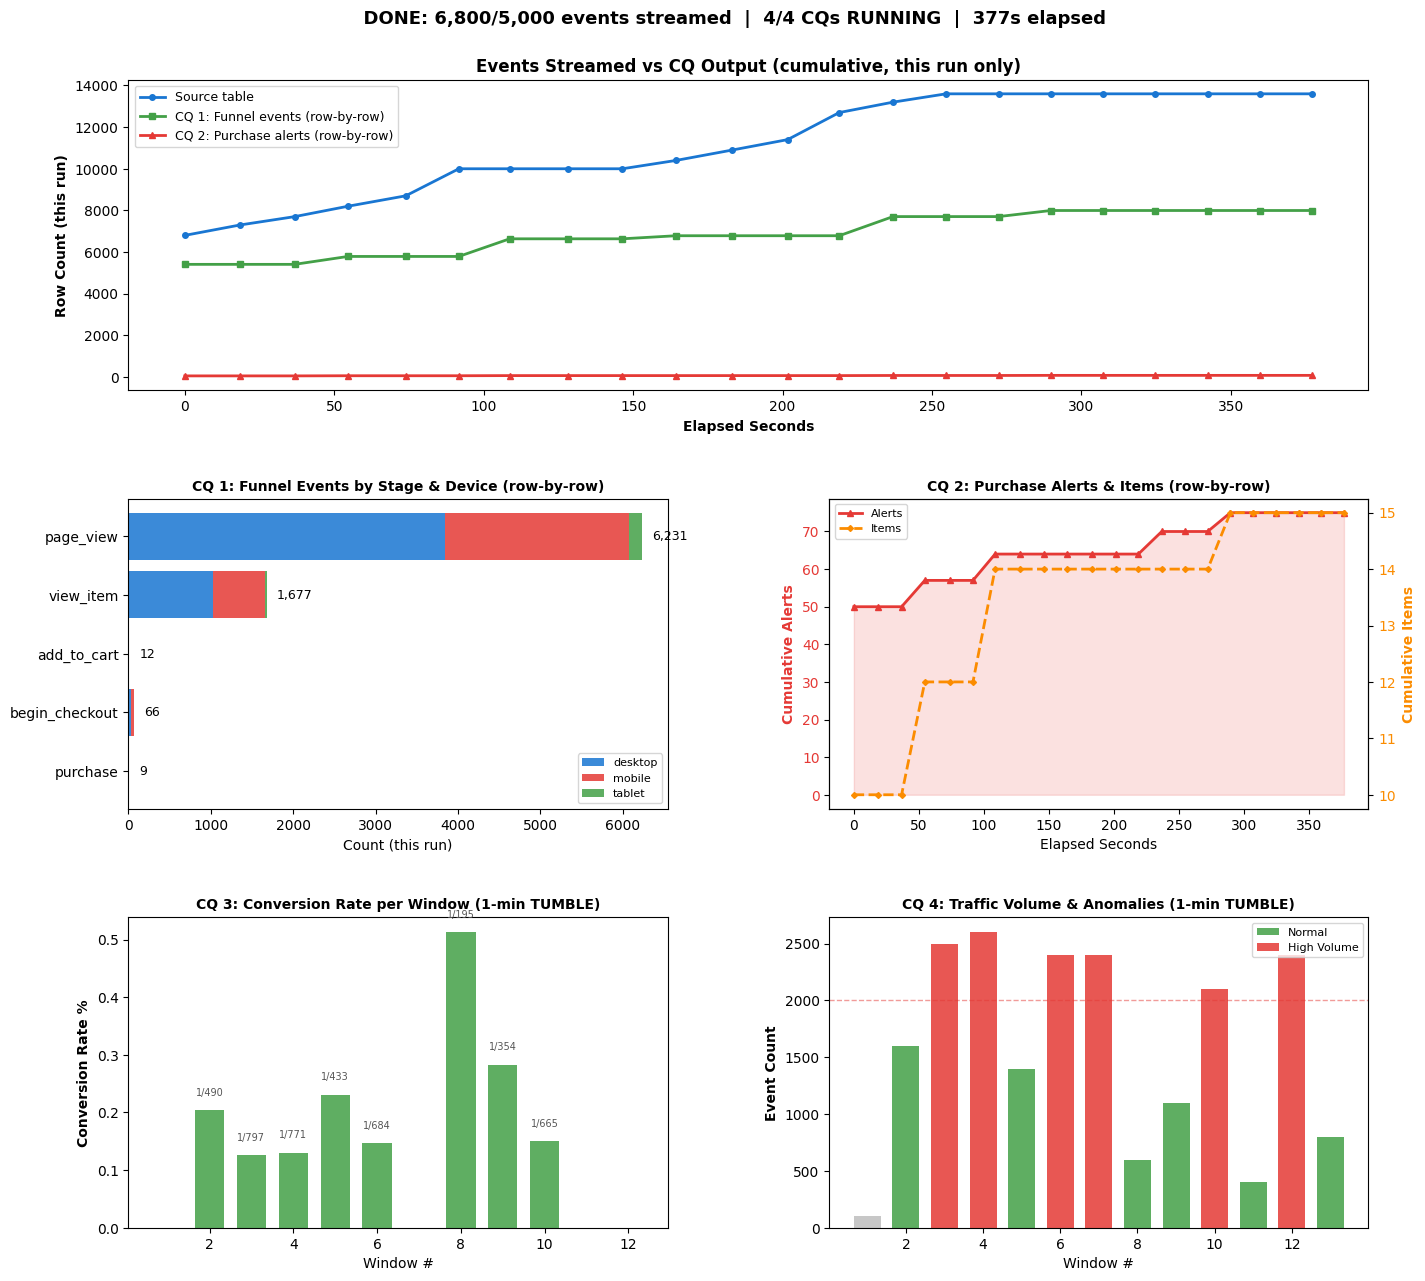


  DASHBOARD COMPLETE
  Events streamed:      6,800
  Stream errors:            0
  Anomaly bursts:           2
  Dashboard runtime:      377s

  Rows written by CQs (since 2026-05-22 13:20:01 UTC):
    funnel_events             7,995 rows
    purchase_alerts              75 rows
    funnel_alerts                93 rows
    traffic_anomalies            13 rows

  CQ job states:
    CQ 1: RUNNING
    CQ 2: RUNNING
    CQ 3: RUNNING
    CQ 4: RUNNING


In [44]:
run_dashboard()

### Run 1 vs Run 2 — What Changed

| Aspect | Run 1 (Section 8) | Run 2 (Section 9) |
|--------|-------------------|-------------------|
| **CQ state** | Cold start — CQs initializing | Warm — CQs already running |
| **Panel 1 delay** | CQ lines may lag behind source line | CQ lines climb with source line (no gap) |
| **Panel 2 counts** | Run 1 events only | Run 1 + Run 2 events combined |
| **Panel 4 windows** | Run 1 windows only | Run 1 + Run 2 windows (more bars) |
| **Panel 5 anomalies** | Bursts at batches 15, 35 | Additional bursts at batches 20, 40 |

The key takeaway: once initialized, continuous queries process new data **immediately** — the same low-latency behavior you'd see with a real GA4 streaming export in production.

### Repeat the Demo

To run the demo again without cleanup, scroll back to **Section 6 — "Read Events from Public Dataset"** and run from there through both dashboards (Sections 8 and 9). The dataset, tables, and reservation already exist, and the zombie cleanup in Section 7 will cancel any CQs from the previous run. The dashboard filters by timestamp so only the new run's data appears on charts.

---
## Production Considerations

| Demo | Production |
|------|------------|
| `events_streaming` (manual inserts) | GA4 streaming export → `events_intraday_*` (automatic) |
| Notebook cell to stream events | GA4 handles this continuously |
| Row-by-row CQs (`funnel_events`, `purchase_alerts`) | Same — instant event classification and alerting |
| Windowed CQs (`funnel_alerts`, `traffic_anomalies`) | Same — feed into dashboards, alerting, or downstream ML |
| Enterprise reservation (100 slots) | Right-size based on data volume and query complexity |

### Two Continuous Query Patterns

| Pattern | How It Works | Latency | Best For |
|---------|-------------|---------|----------|
| **Row-by-row** (`APPENDS` only) | Processes each new row individually as it arrives | Seconds | Event classification, instant alerts, enrichment |
| **Windowed** (`APPENDS` + `TUMBLE`) | Aggregates rows within time windows, emits when window closes | Window duration | Conversion rates, volume trends, anomaly detection |

### Destination Options

Continuous queries aren't limited to BigQuery tables. You can also write to:
- **[Pub/Sub](https://cloud.google.com/bigquery/docs/continuous-queries-pub-sub)** — trigger Cloud Functions, push to Slack, send emails
- **[Bigtable](https://cloud.google.com/bigquery/docs/continuous-queries-bigtable)** — serve alerts at sub-10ms latency
- **[Spanner](https://cloud.google.com/bigquery/docs/continuous-queries-spanner)** — write to a globally distributed relational database
- **Another BigQuery table** — chain continuous queries for multi-stage processing

### Architecture

```
GA4 Property                    BigQuery
┌──────────┐    streaming     ┌──────────────────────────┐
│  Website  │───export──────▶ │  events_streaming         │
│  / App   │  (or our sim)   │  (source table)           │
└──────────┘                  └──────────┬────────────────┘
                                         │
                              ┌──────────┴────────────────┐
                              │    CONTINUOUS QUERIES      │
                              │                            │
                              │  Row-by-row    Windowed    │
                              │  (APPENDS)   (APPENDS +    │
                              │               TUMBLE)      │
                              └──┬────┬────────┬─────┬────┘
                                 │    │        │     │
                              ┌──▼──┐ ▼──────┐ ▼───┐ ▼────────┐
                              │funnel│purchase│funnel│ traffic  │
                              │_evts │_alerts │_alrts│_anomalies│
                              └─────┘└───────┘└─────┘└─────────┘
```

---
## 10. Cleanup

Delete all resources to stop billing. Order matters:
1. Cancel 4 continuous query jobs (they run indefinitely until cancelled)
2. Delete reservation assignment → reservation (reverse creation order)
3. Delete dataset and all 5 tables

> **The reservation is the most important to clean up** — slots are billed per-second while it exists, even if no queries are running.

In [32]:
raise RuntimeError(
    'STOP — Cleanup deletes all resources (reservation, dataset, tables).\n'
    'To proceed, run each cleanup cell below individually.'
)

RuntimeError: STOP — Cleanup deletes all resources (reservation, dataset, tables).
To proceed, run each cleanup cell below individually.

### Step 1: Cancel Continuous Queries

Continuous queries are long-running jobs — cancel them by job ID.

In [45]:
for job_id in cq_jobs:
    try:
        bq.cancel_job(job_id)
        print(f'Cancelled continuous query job: {job_id}')
    except Exception as e:
        print(f'Could not cancel {job_id}: {e}')

if not cq_jobs:
    print('No continuous query jobs in cq_jobs list.')

# Safety net: scan INFORMATION_SCHEMA for any CQ jobs we missed
remaining = bq.query(f'''
    SELECT job_id
    FROM `{BQ_PROJECT}.region-{BQ_LOCATION.lower()}`.INFORMATION_SCHEMA.JOBS
    WHERE state = 'RUNNING'
        AND creation_time > TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 7 DAY)
        AND LOWER(query) LIKE '%appends%'
        AND LOWER(query) LIKE '%insert into%'
        AND LOWER(query) LIKE '%{BQ_DATASET.lower()}%'
''').to_dataframe()

extra = 0
for _, row in remaining.iterrows():
    if row['job_id'] not in cq_jobs:
        try:
            bq.cancel_job(row['job_id'], location=BQ_LOCATION)
            print(f'Cancelled zombie: {row["job_id"]}')
            extra += 1
        except Exception:
            pass

if extra:
    print(f'\nCancelled {extra} additional zombie CQ(s).')
else:
    print('No zombie CQs found.')

Cancelled continuous query job: 7bb3aeeb-edbc-41aa-b6d7-e052a9aea51a
Cancelled continuous query job: e29add9e-5f9c-4a44-97c4-d413ea772590
Cancelled continuous query job: f5e0b18a-64d0-42fa-9165-461067b7f62b
Cancelled continuous query job: 7e2bdac8-b2e1-49f7-98c9-4f234b2f7f1d
No zombie CQs found.


### Step 2: Delete Reservation

Delete assignments first — the API rejects deletion of a reservation that still has assignments.

In [46]:
parent = f'projects/{PROJECT_ID}/locations/{BQ_LOCATION}'
reservation_name = f'{parent}/reservations/{RESERVATION_ID}'

print('Cleaning up reservation resources...')

try:
    assignments = list(reservation_client.list_assignments(parent=reservation_name))
    for a in assignments:
        reservation_client.delete_assignment(name=a.name)
        print(f'  Deleted assignment: {a.name}')
except NotFound:
    print('  No assignments found')
except Exception as e:
    print(f'  Assignment cleanup: {e}')

try:
    reservation_client.delete_reservation(name=reservation_name)
    print(f'  Deleted reservation: {reservation_name}')
except NotFound:
    print('  Reservation already deleted')
except Exception as e:
    print(f'  Reservation cleanup: {e}')

print('\nReservation cleanup complete.')

Cleaning up reservation resources...
  Deleted assignment: projects/statmike-mlops-349915/locations/US/reservations/ga4-continuous-demo/assignments/10498276144515700580
  Deleted reservation: projects/statmike-mlops-349915/locations/US/reservations/ga4-continuous-demo

Reservation cleanup complete.


### Step 3: Verify Reservation Cleanup

In [47]:
remaining = list(reservation_client.list_reservations(parent=parent))
our_reservations = [r for r in remaining if RESERVATION_ID in r.name]
if our_reservations:
    print(f'WARNING: Reservation still exists: {our_reservations[0].name}')
    print('  This will continue to incur slot charges.')
else:
    print(f'Reservation {RESERVATION_ID} successfully deleted.')
    print('No ongoing slot charges.')

Reservation ga4-continuous-demo successfully deleted.
No ongoing slot charges.


### Step 4: Delete Dataset and Tables

In [48]:
for table_name in [BQ_TABLE_EVENTS, BQ_TABLE_FUNNEL_EVENTS, BQ_TABLE_PURCHASE_ALERTS, BQ_TABLE_FUNNEL, BQ_TABLE_ANOMALY]:
    bq.delete_table(f'{BQ_PROJECT}.{BQ_DATASET}.{table_name}', not_found_ok=True)
    print(f'Deleted table: {table_name}')

bq.delete_dataset(f'{BQ_PROJECT}.{BQ_DATASET}', delete_contents=True, not_found_ok=True)
print(f'\nDeleted dataset: {BQ_PROJECT}.{BQ_DATASET}')
print('All resources cleaned up.')

Deleted table: events_streaming
Deleted table: funnel_events
Deleted table: purchase_alerts
Deleted table: funnel_alerts
Deleted table: traffic_anomalies

Deleted dataset: statmike-mlops-349915.ga4_continuous_queries
All resources cleaned up.
